In [1]:
from utils import (
    load_nested_results,
    compute_shap_similarity_pearson,
    compute_shap_ndcg_similarity,
)

all_results = load_nested_results("results_all/")

In [5]:
models_names

['AutoEncoder',
 'CBLOF',
 'COPOD',
 'DeepSVDD',
 'ECOD',
 'GMM',
 'HBOS',
 'IForest',
 'KNN',
 'LODA',
 'LOF',
 'MCD',
 'OCSVM',
 'PCA']

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from scipy.stats import rankdata


datasets_names = list(all_results.keys())
n_fold = 5
n_models_ensemblist = 2

plot_data = {}

for dataset in datasets_names:

    all_triplet_data_for_dataset = []

    shap_similarities, models_names = compute_shap_similarity_pearson(
        all_results[dataset]
    )
    shap_ndcg, _ = compute_shap_ndcg_similarity(all_results[dataset])

    all_triplets_indices = combinations(range(len(models_names)), n_models_ensemblist)

    for triplet_indices in all_triplets_indices:
        i, j = triplet_indices

        fold_auc = []

        name = f"{i}-{j}"

        for fold in range(n_fold):
            y_true = all_results[dataset]["ground_truth"][fold]

            ranks_1 = rankdata(
                all_results[dataset][models_names[i]][fold]["scores"], "average"
            )
            ranks_2 = rankdata(
                all_results[dataset][models_names[j]][fold]["scores"], "average"
            )
            auc_rank = roc_auc_score(y_true, (ranks_1 + ranks_2) / 2)

            fold_auc.append(auc_rank)

        all_triplet_data_for_dataset.append(
            (
                np.nanmean(fold_auc),  # Mean AUC
                name,  # name
                shap_similarities[i, j],  # SHAP
                shap_ndcg[i, j],
            )
        )

    plot_data[dataset] = all_triplet_data_for_dataset

/opt/homebrew/Caskroom/miniforge/base/envs/shapspace/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/shapspace/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/shapspace/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/shapspace/lib/python3.12/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/envs/shapspace/lib

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.
/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


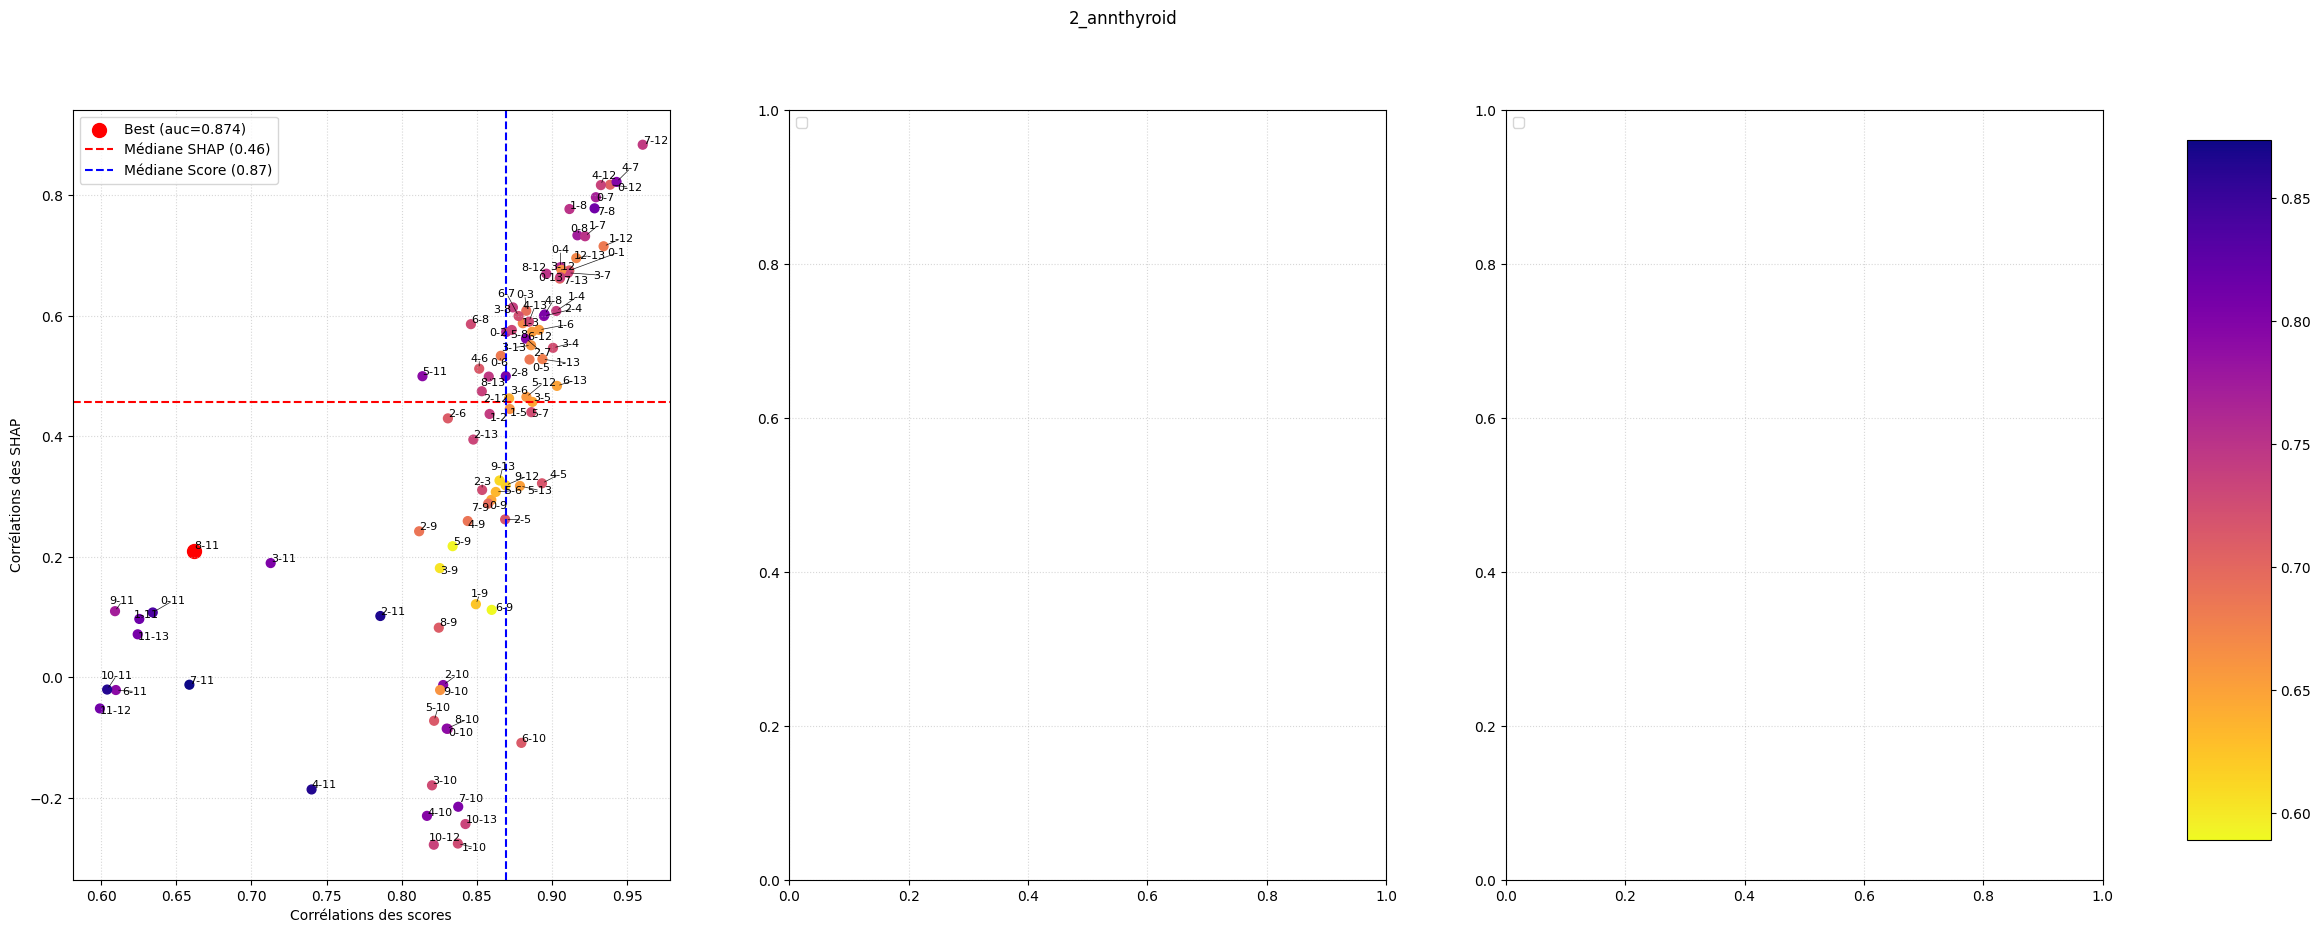

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


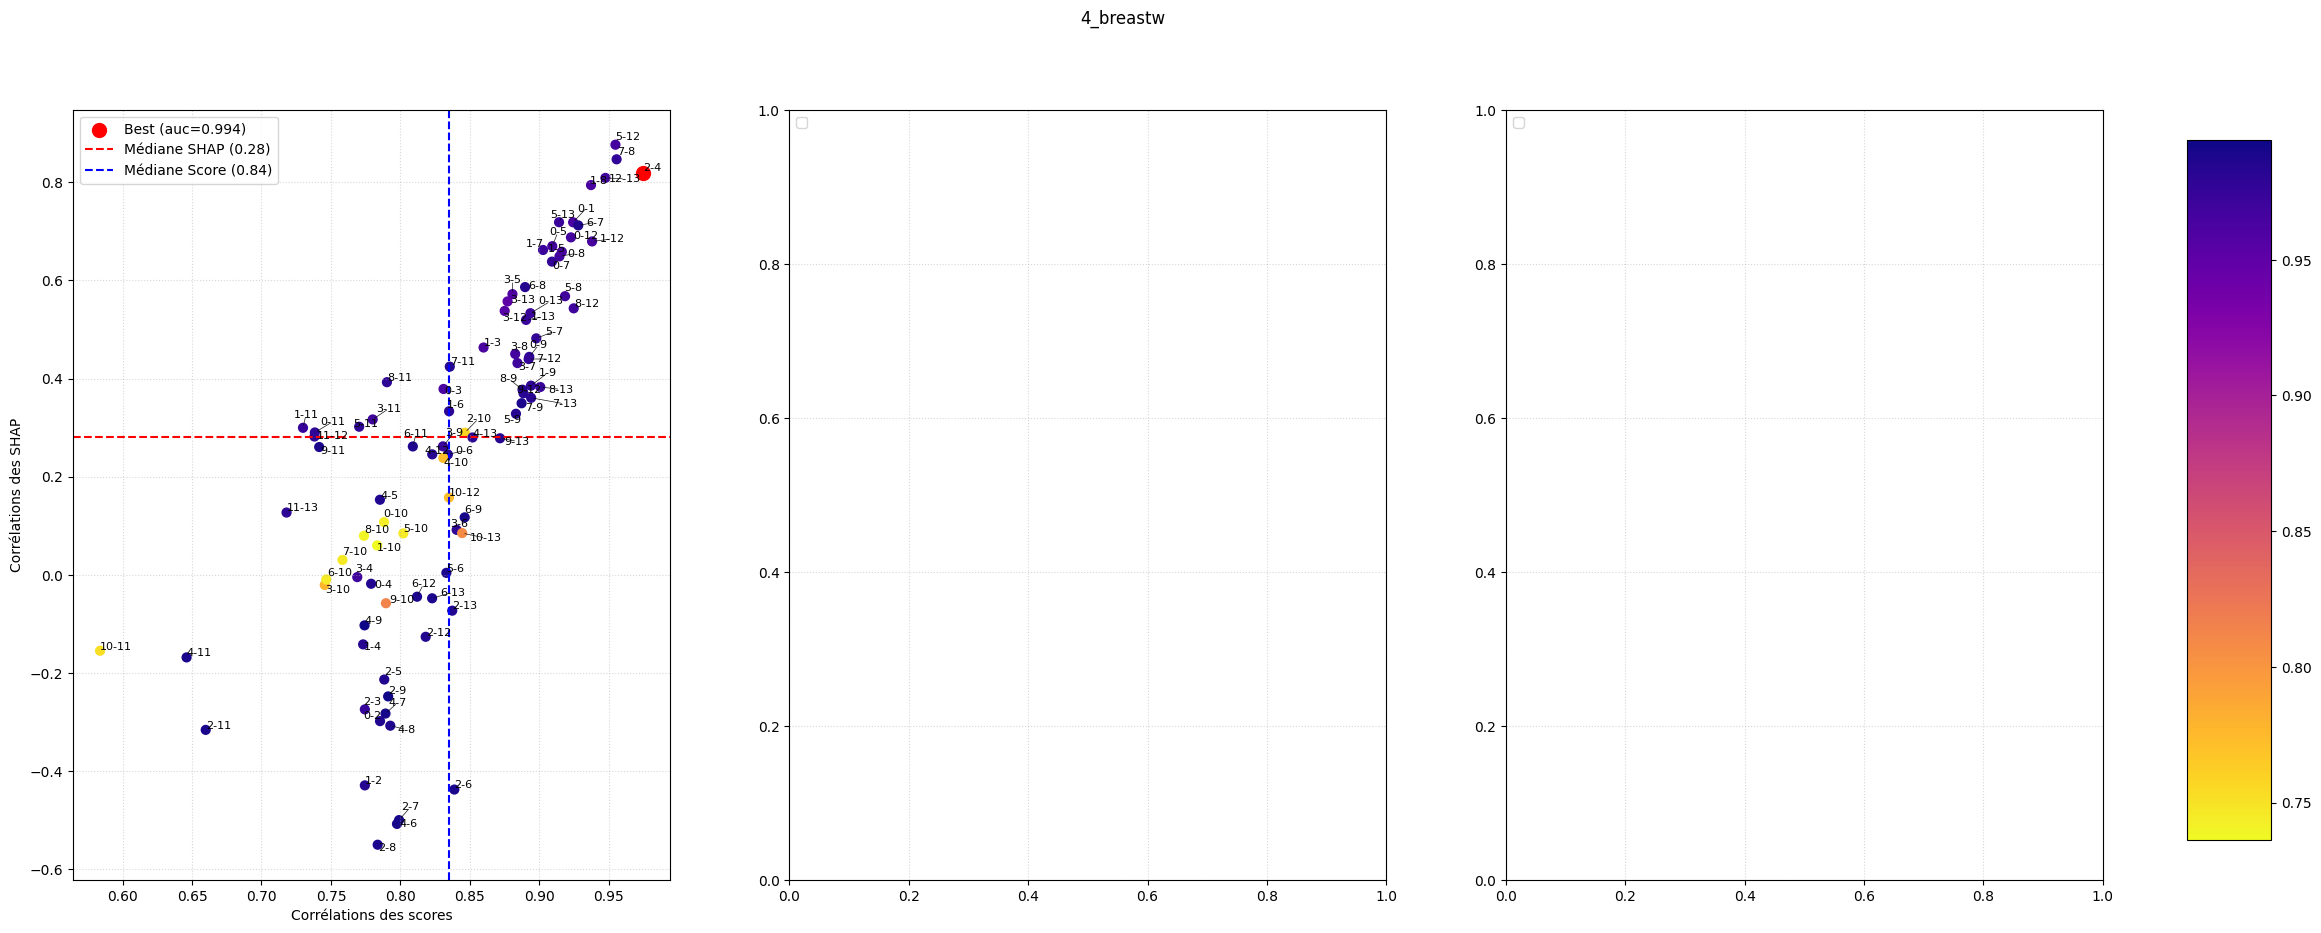

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


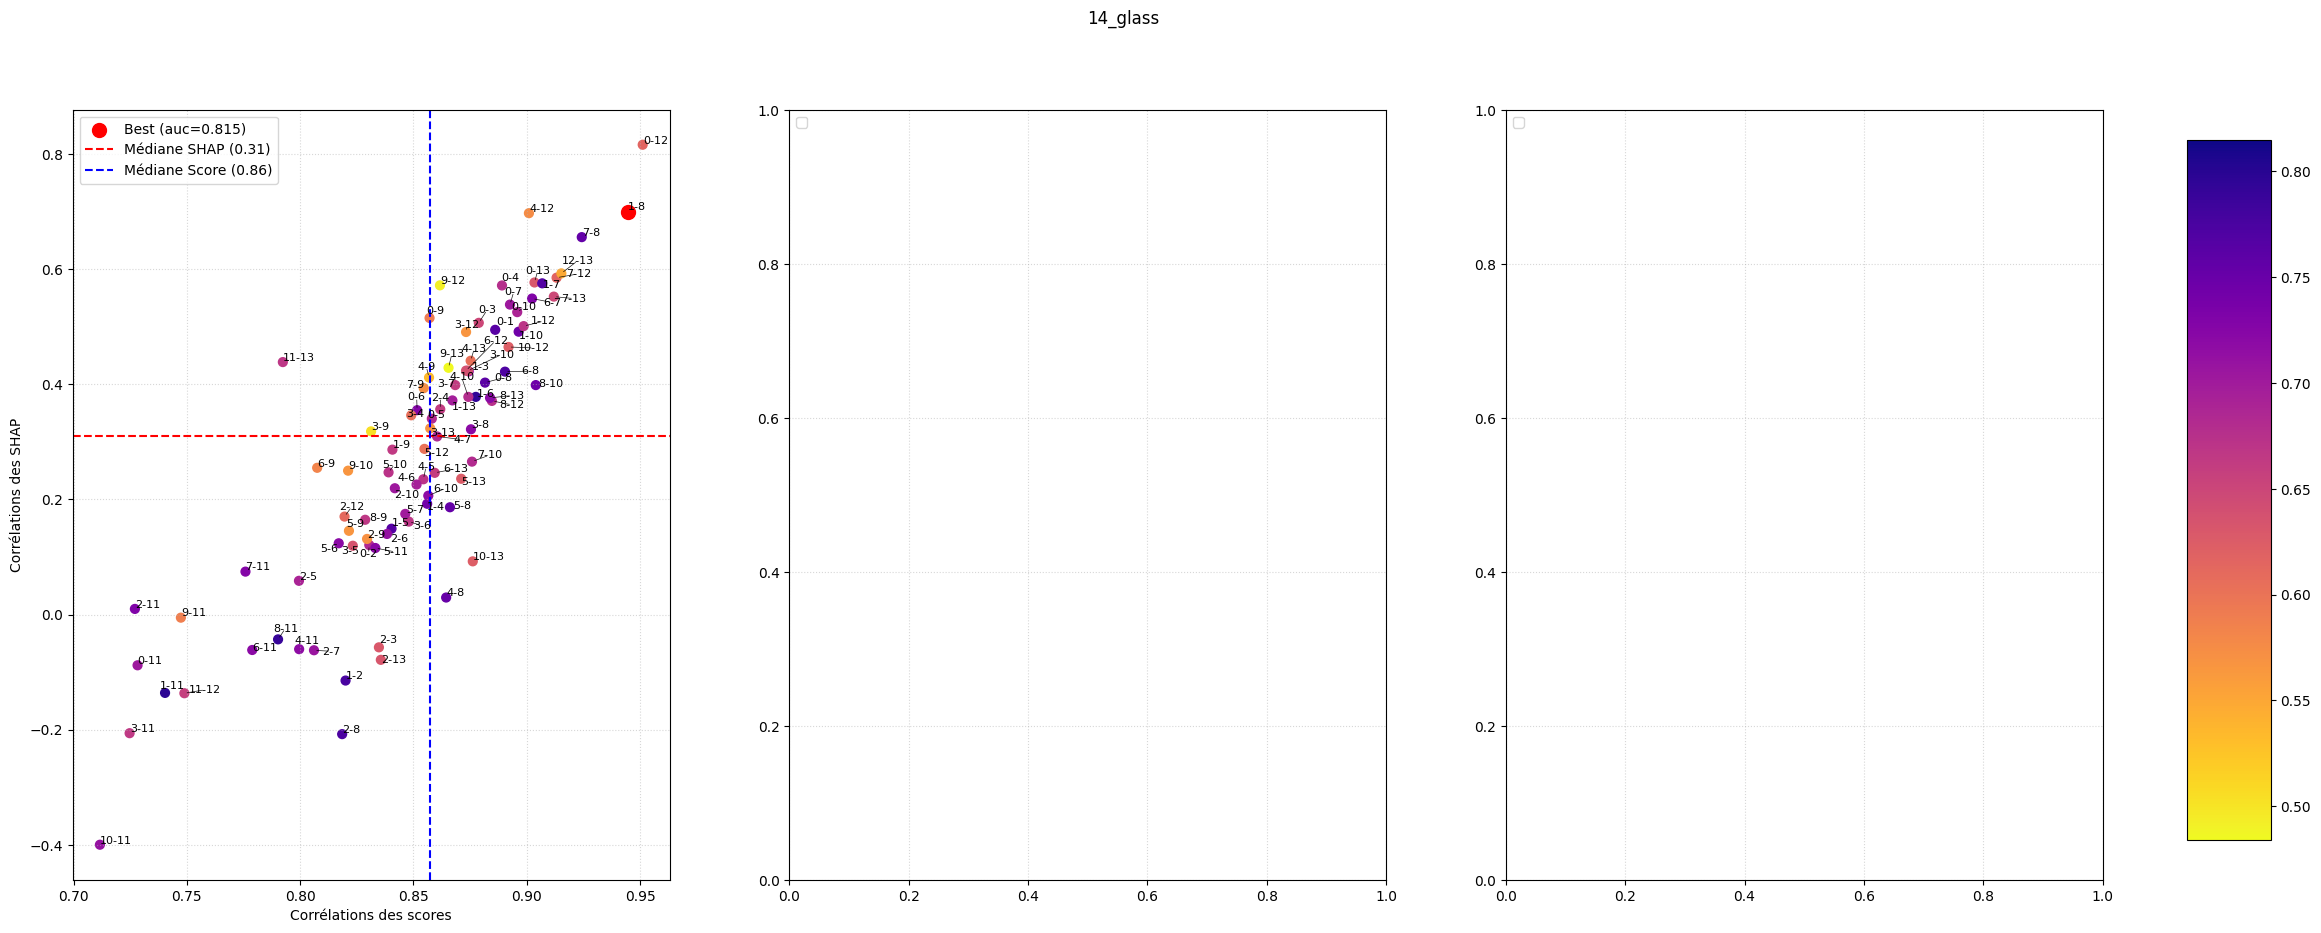

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


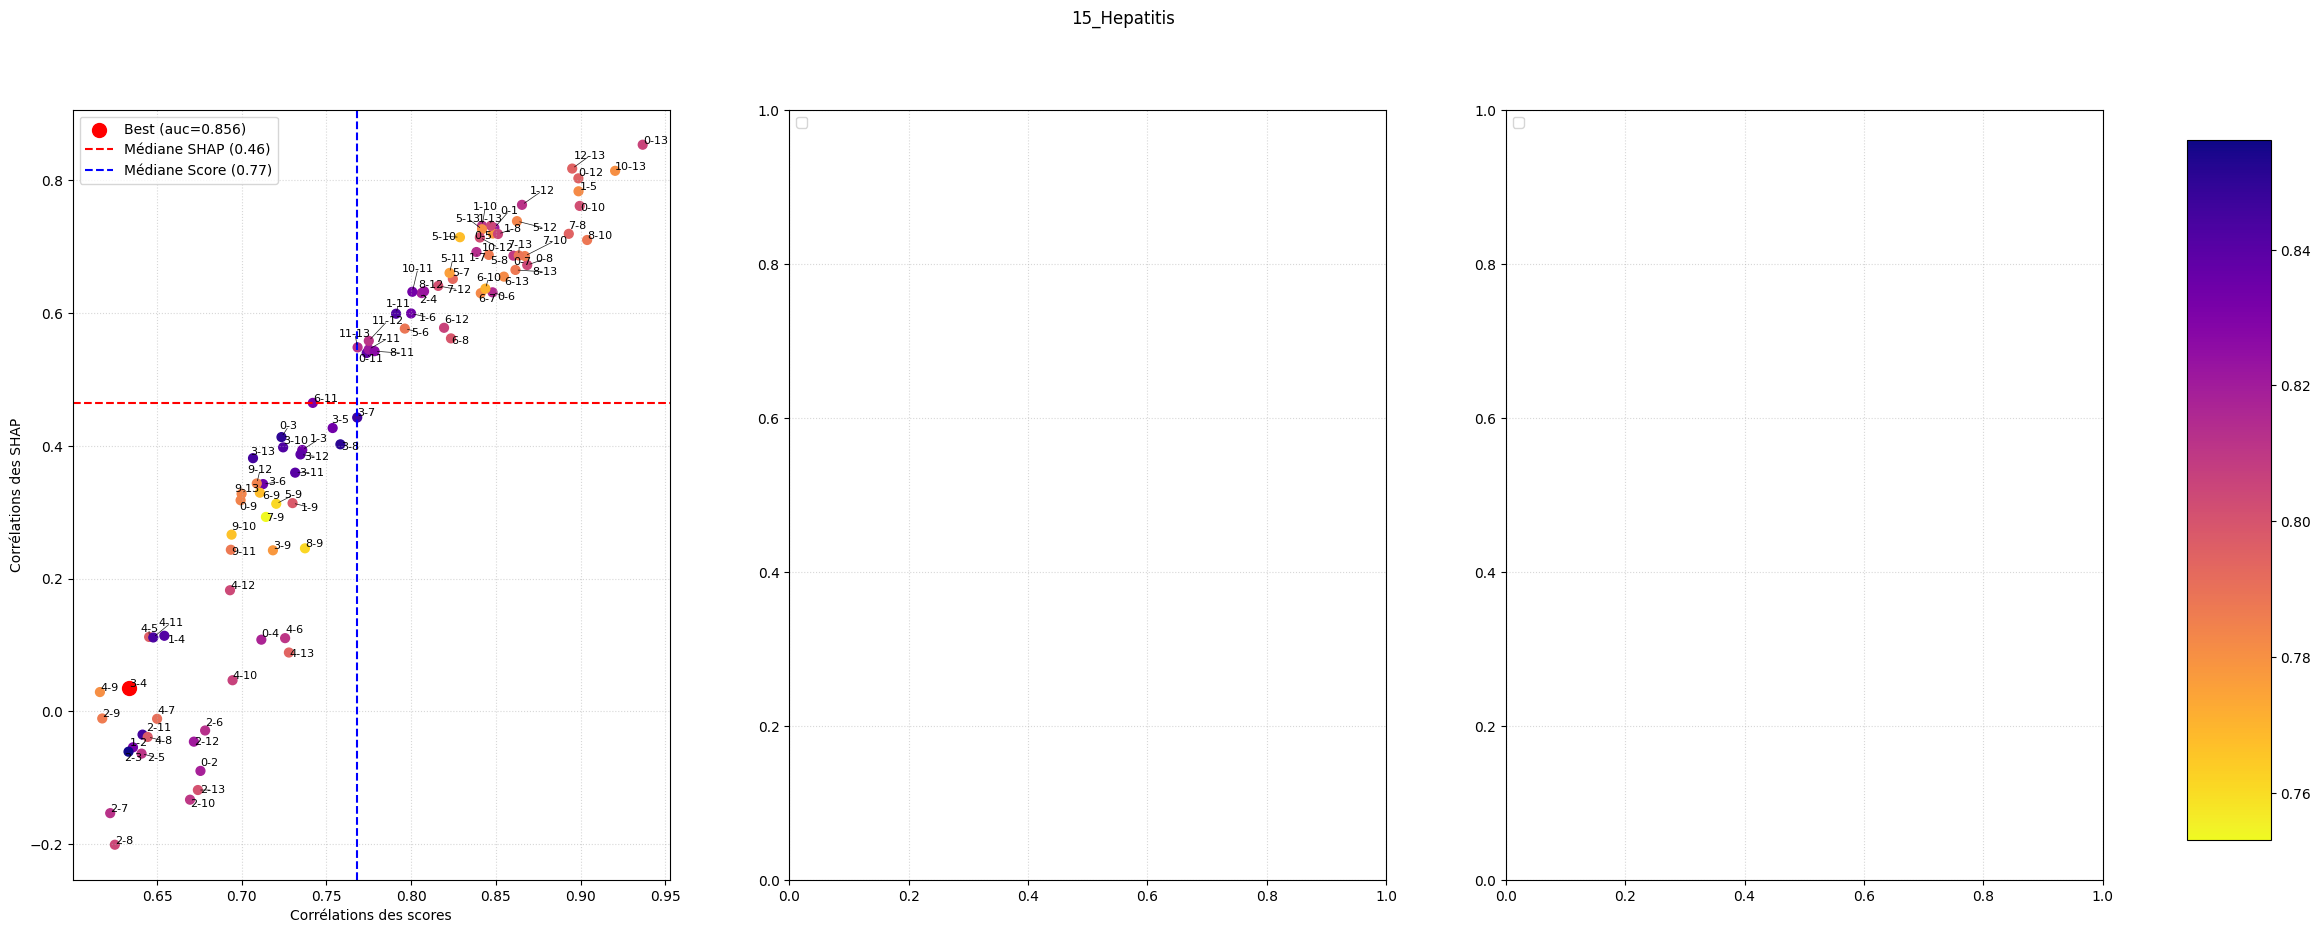

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


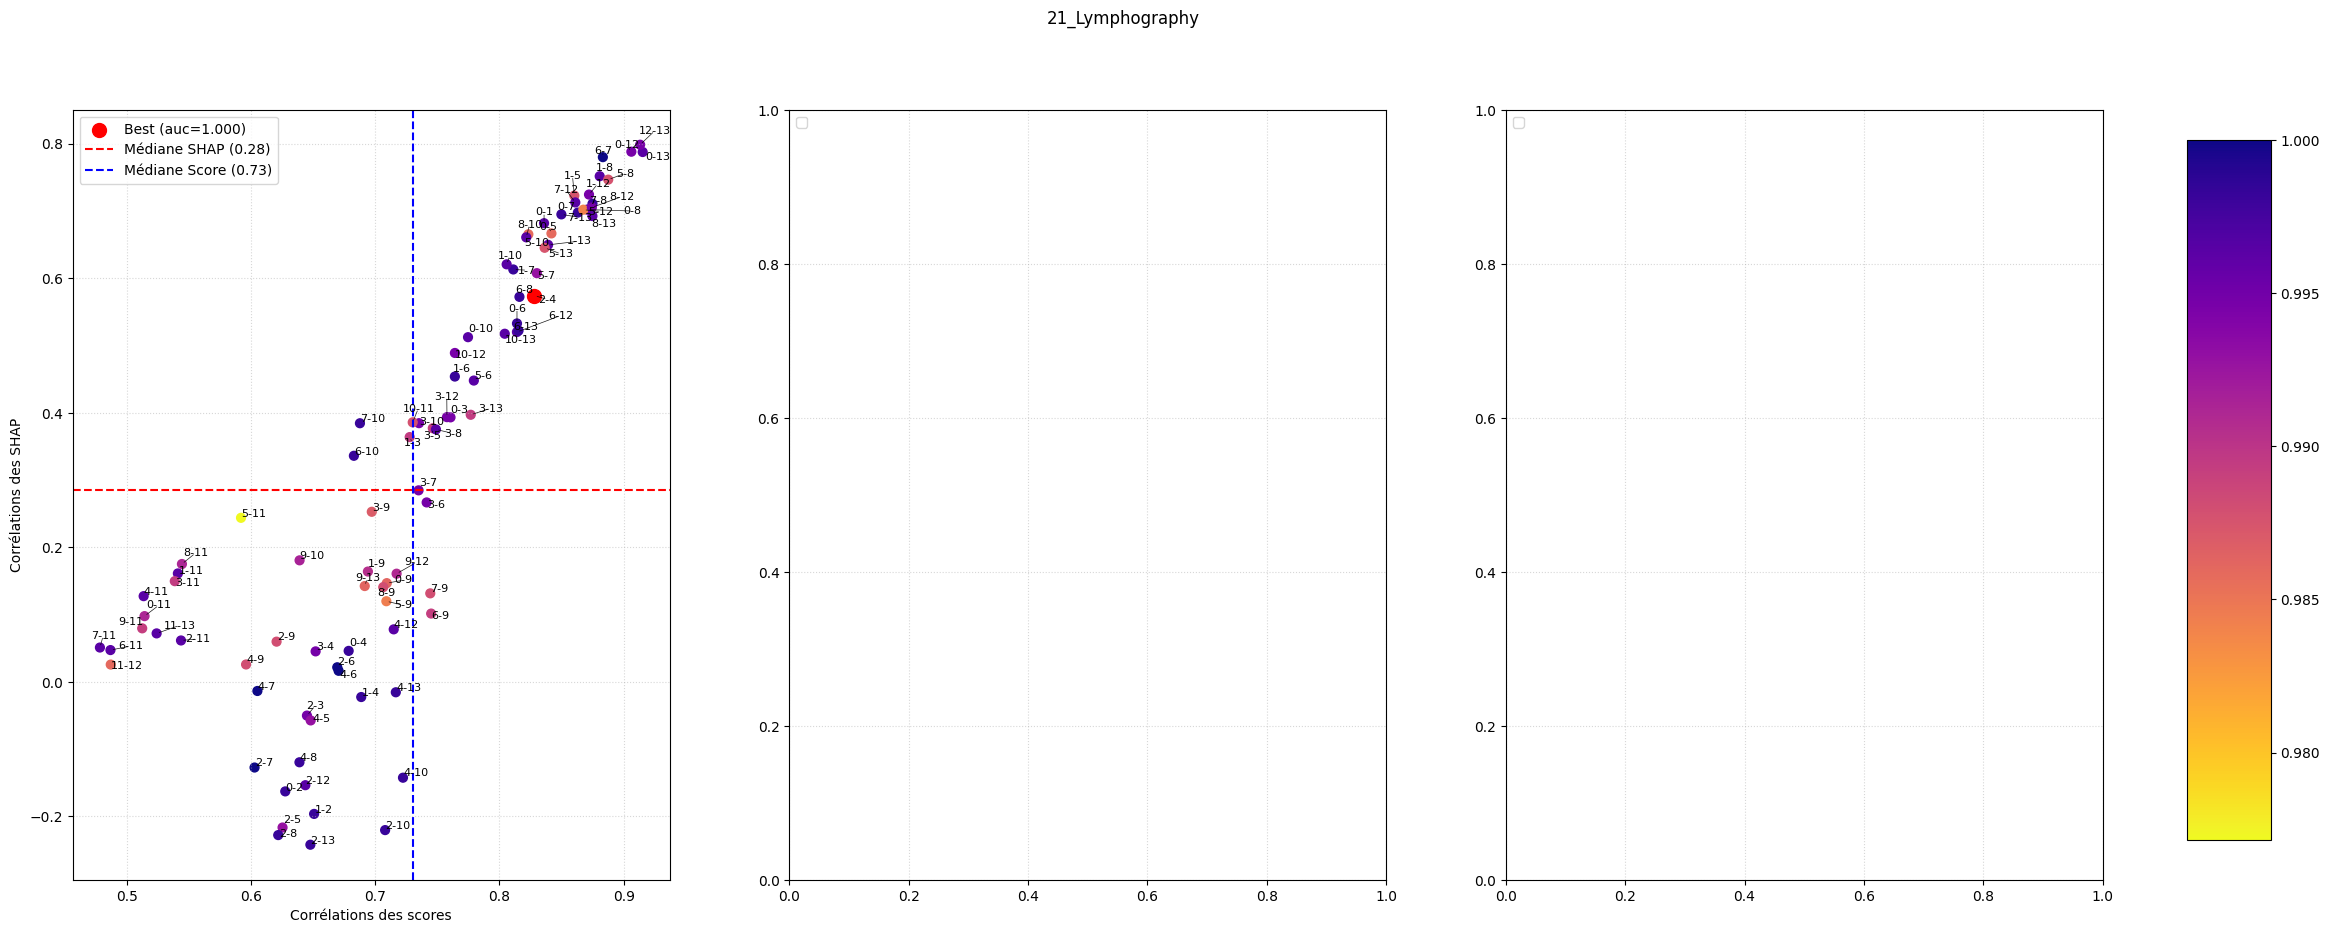

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


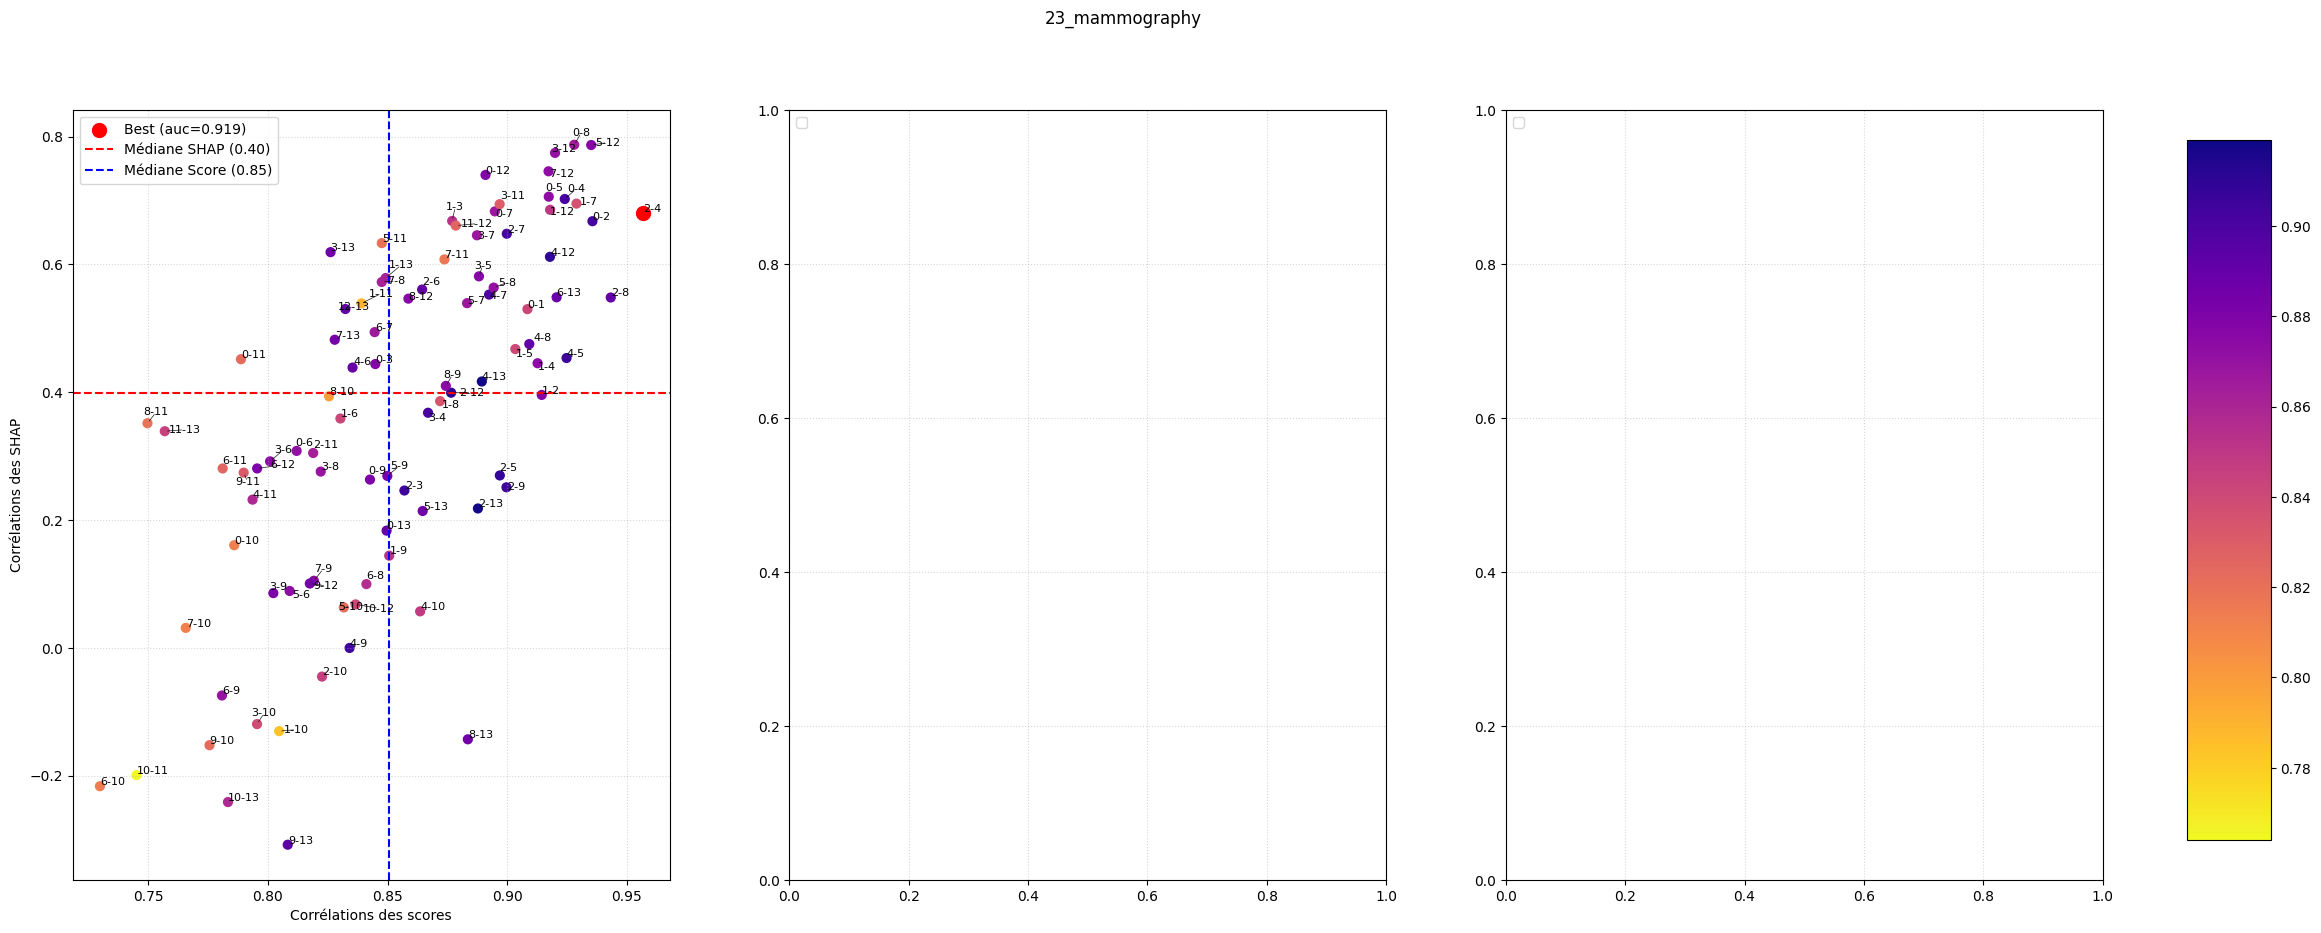

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


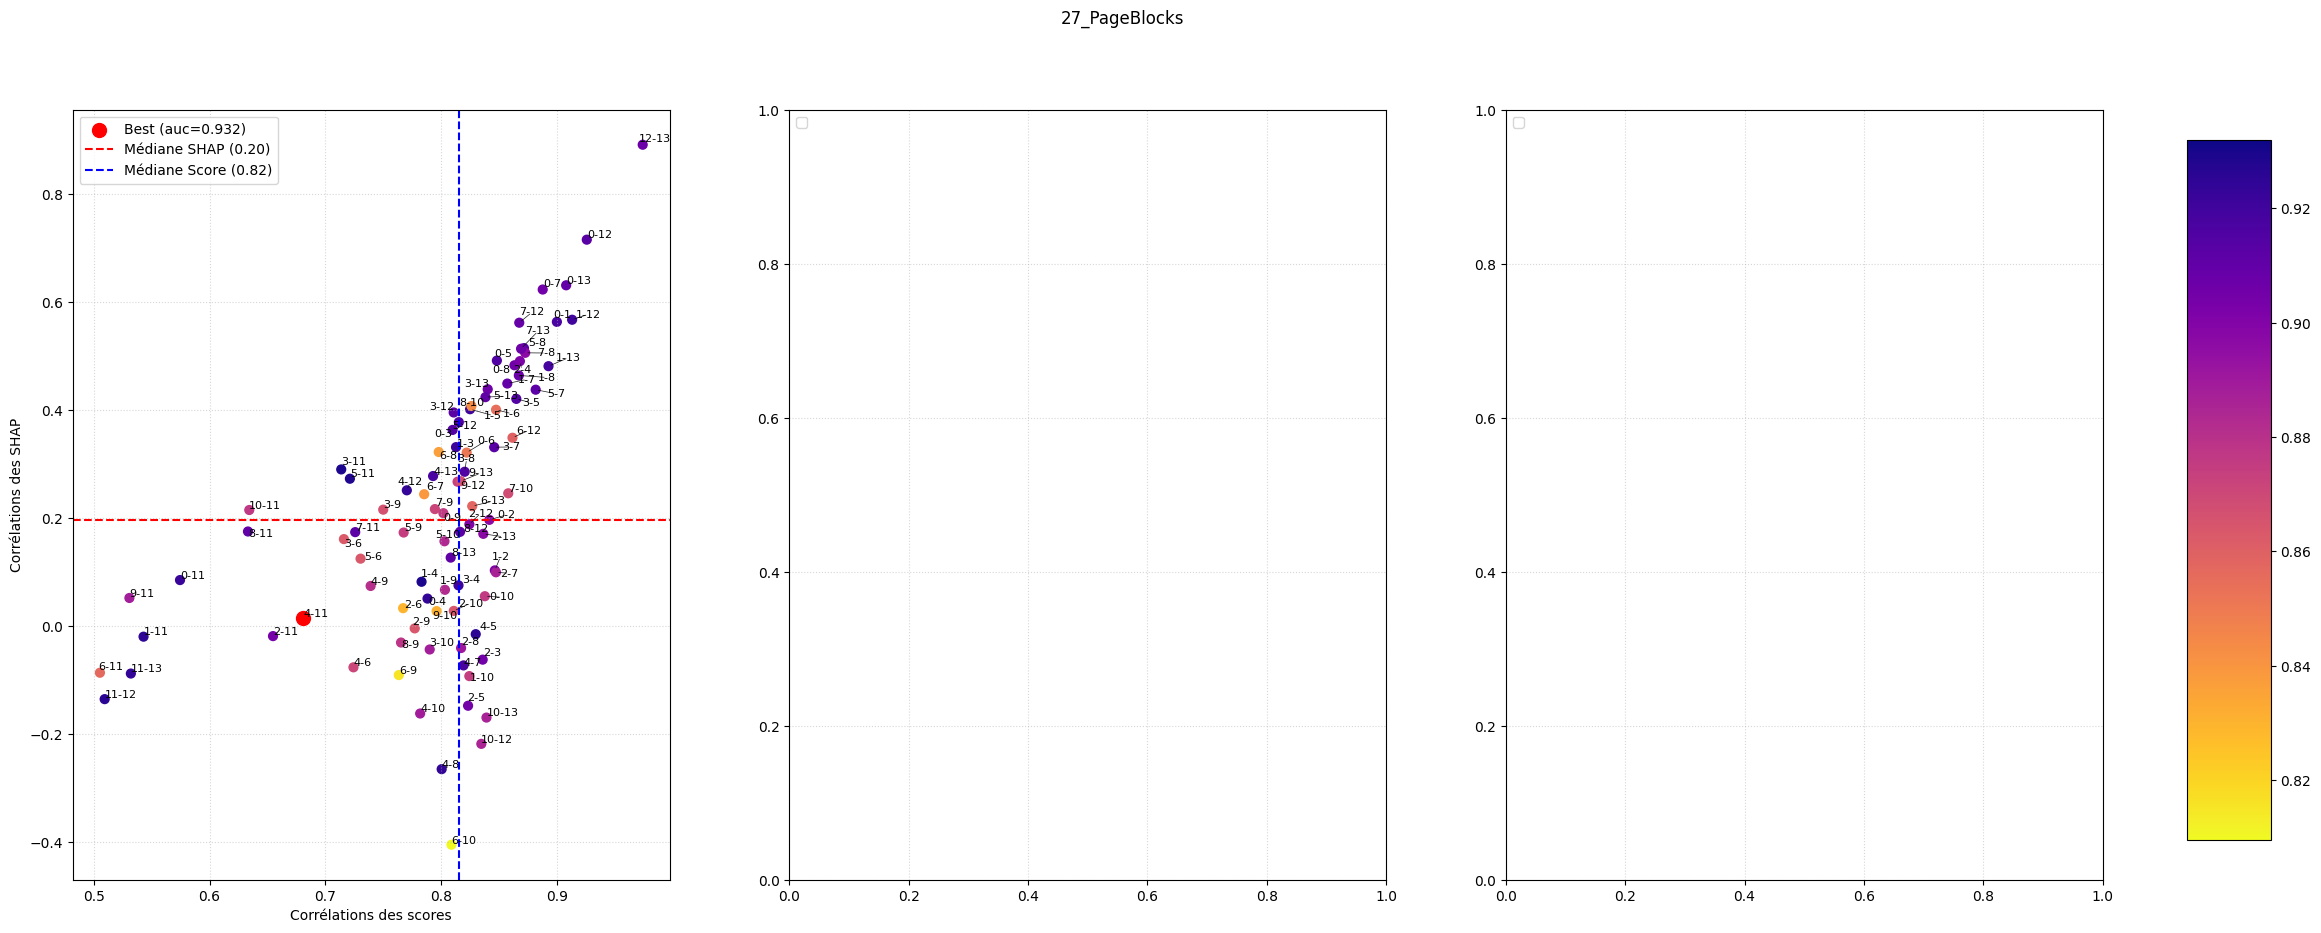

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


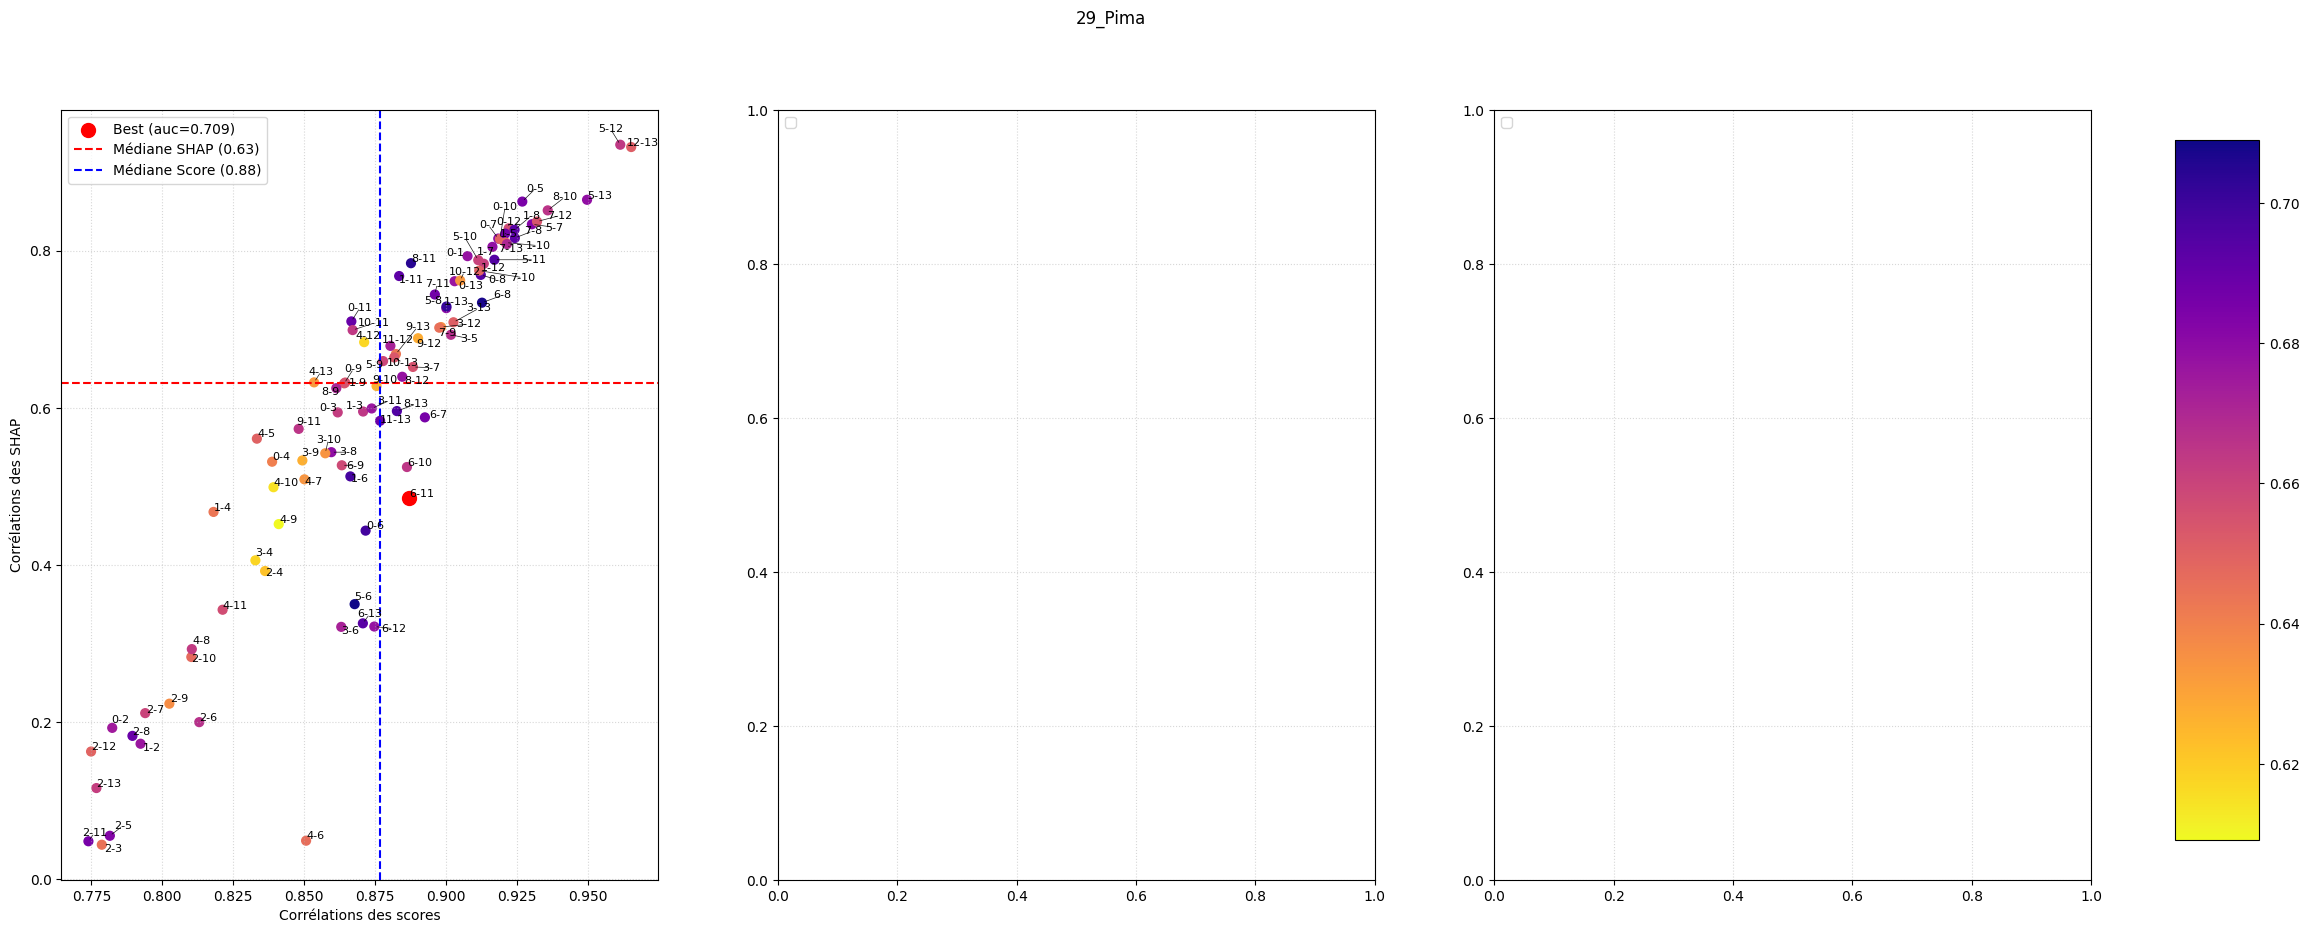

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


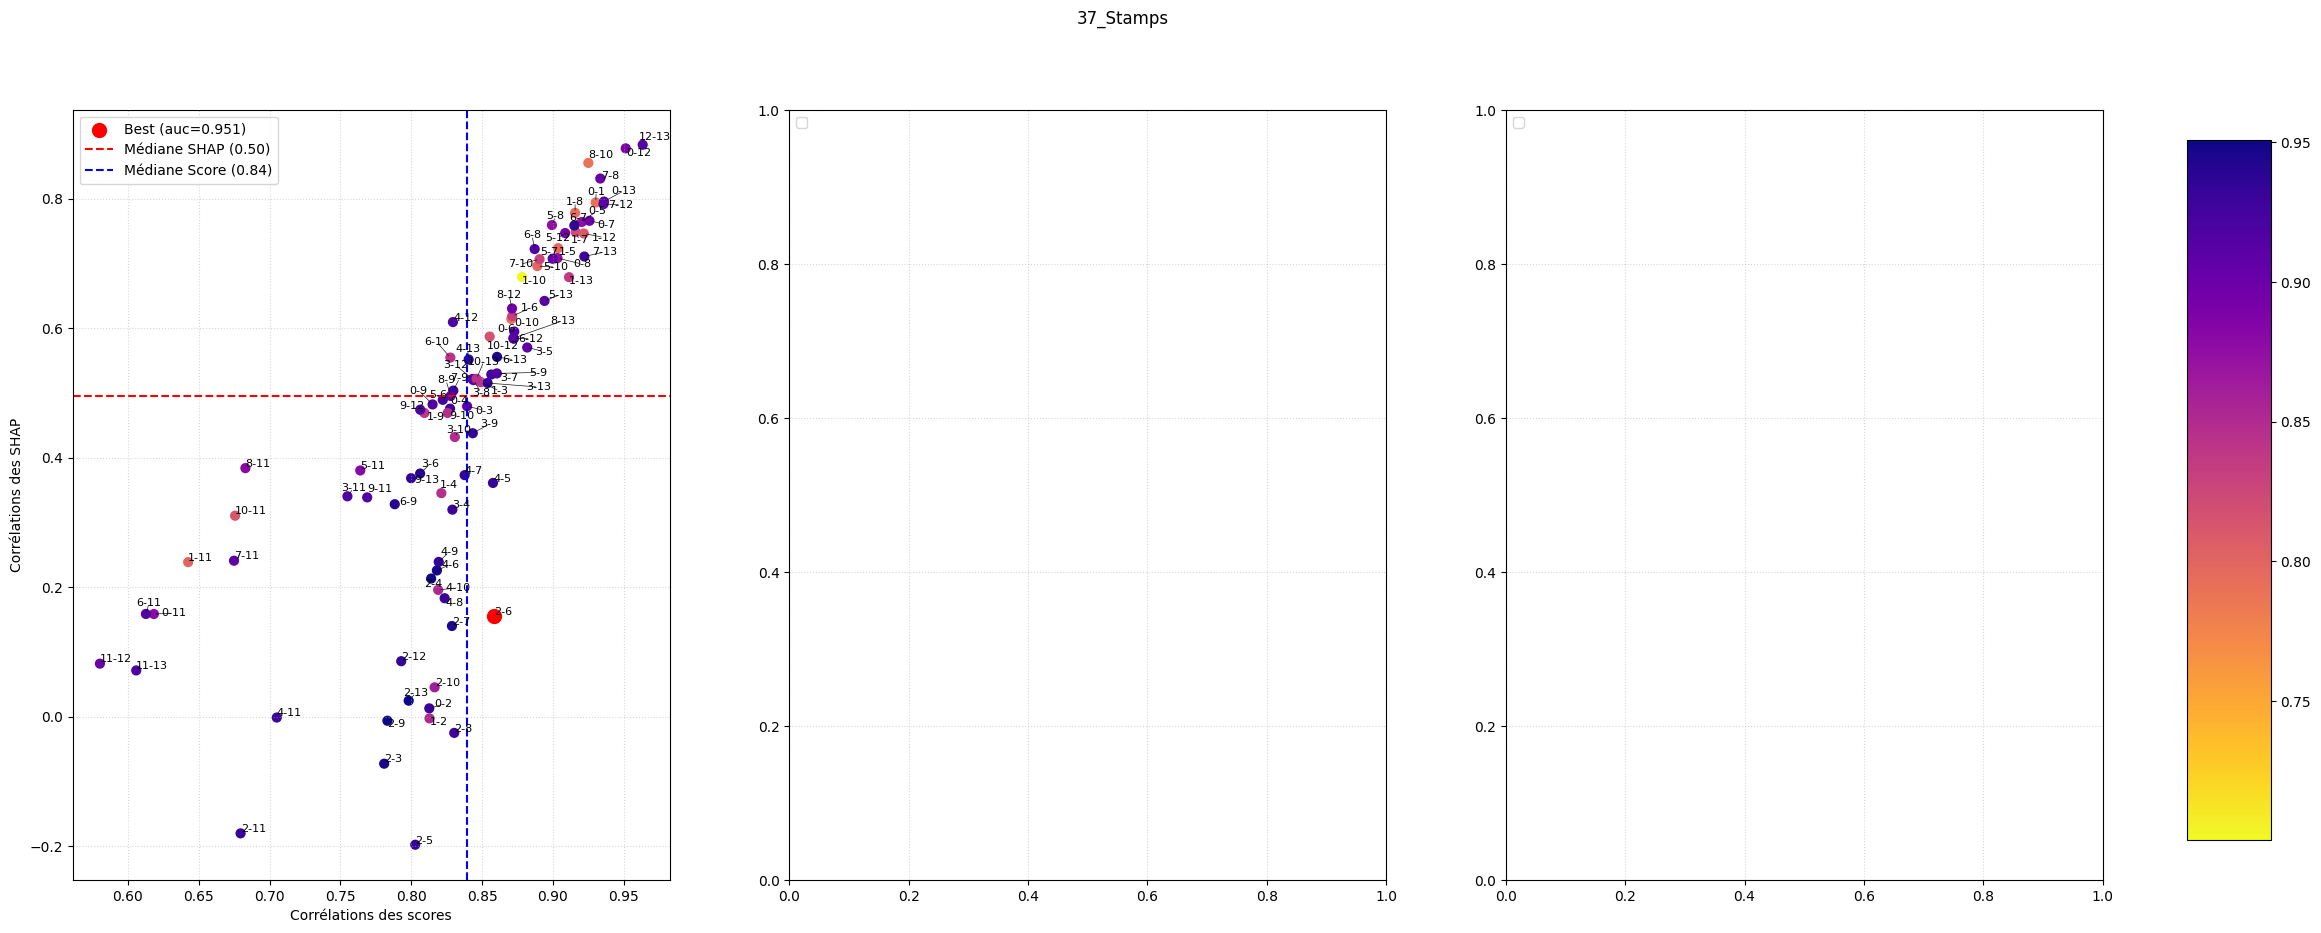

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


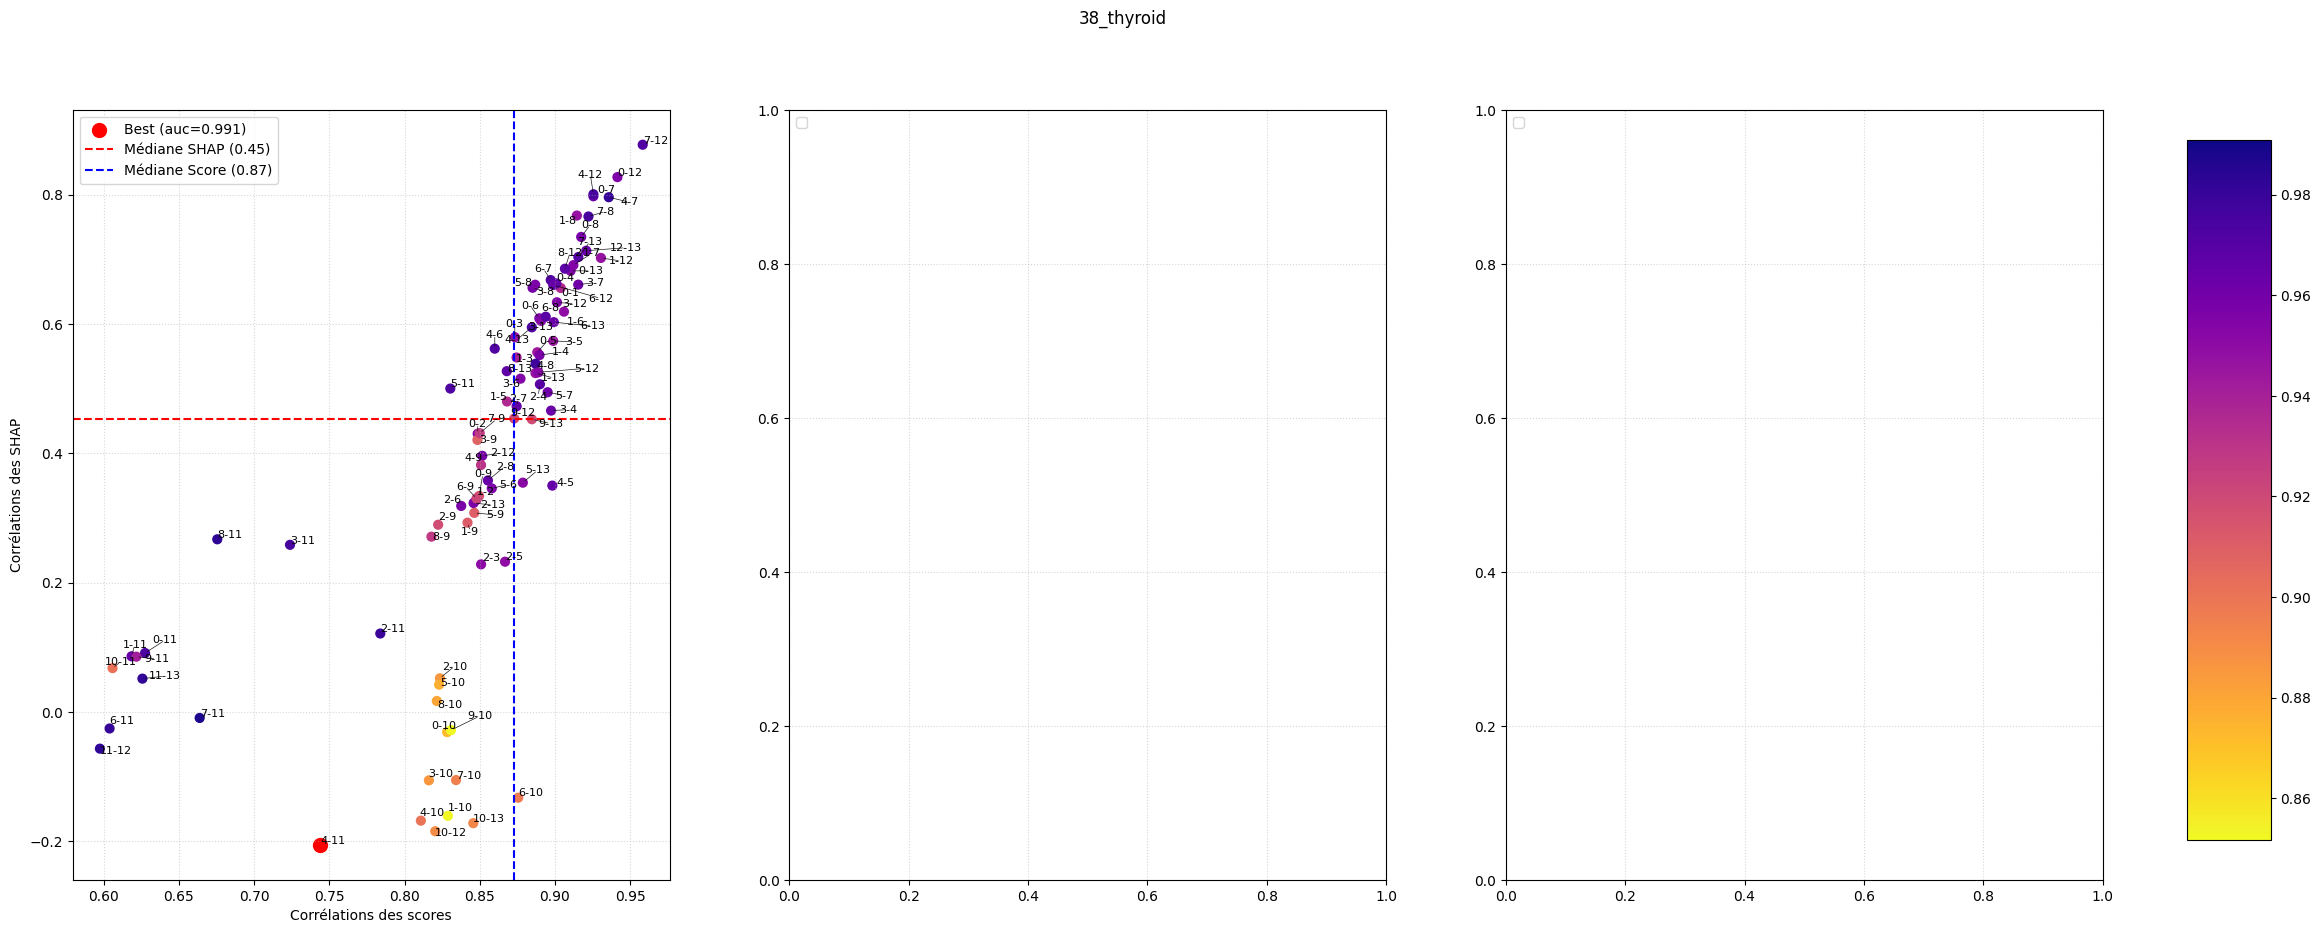

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


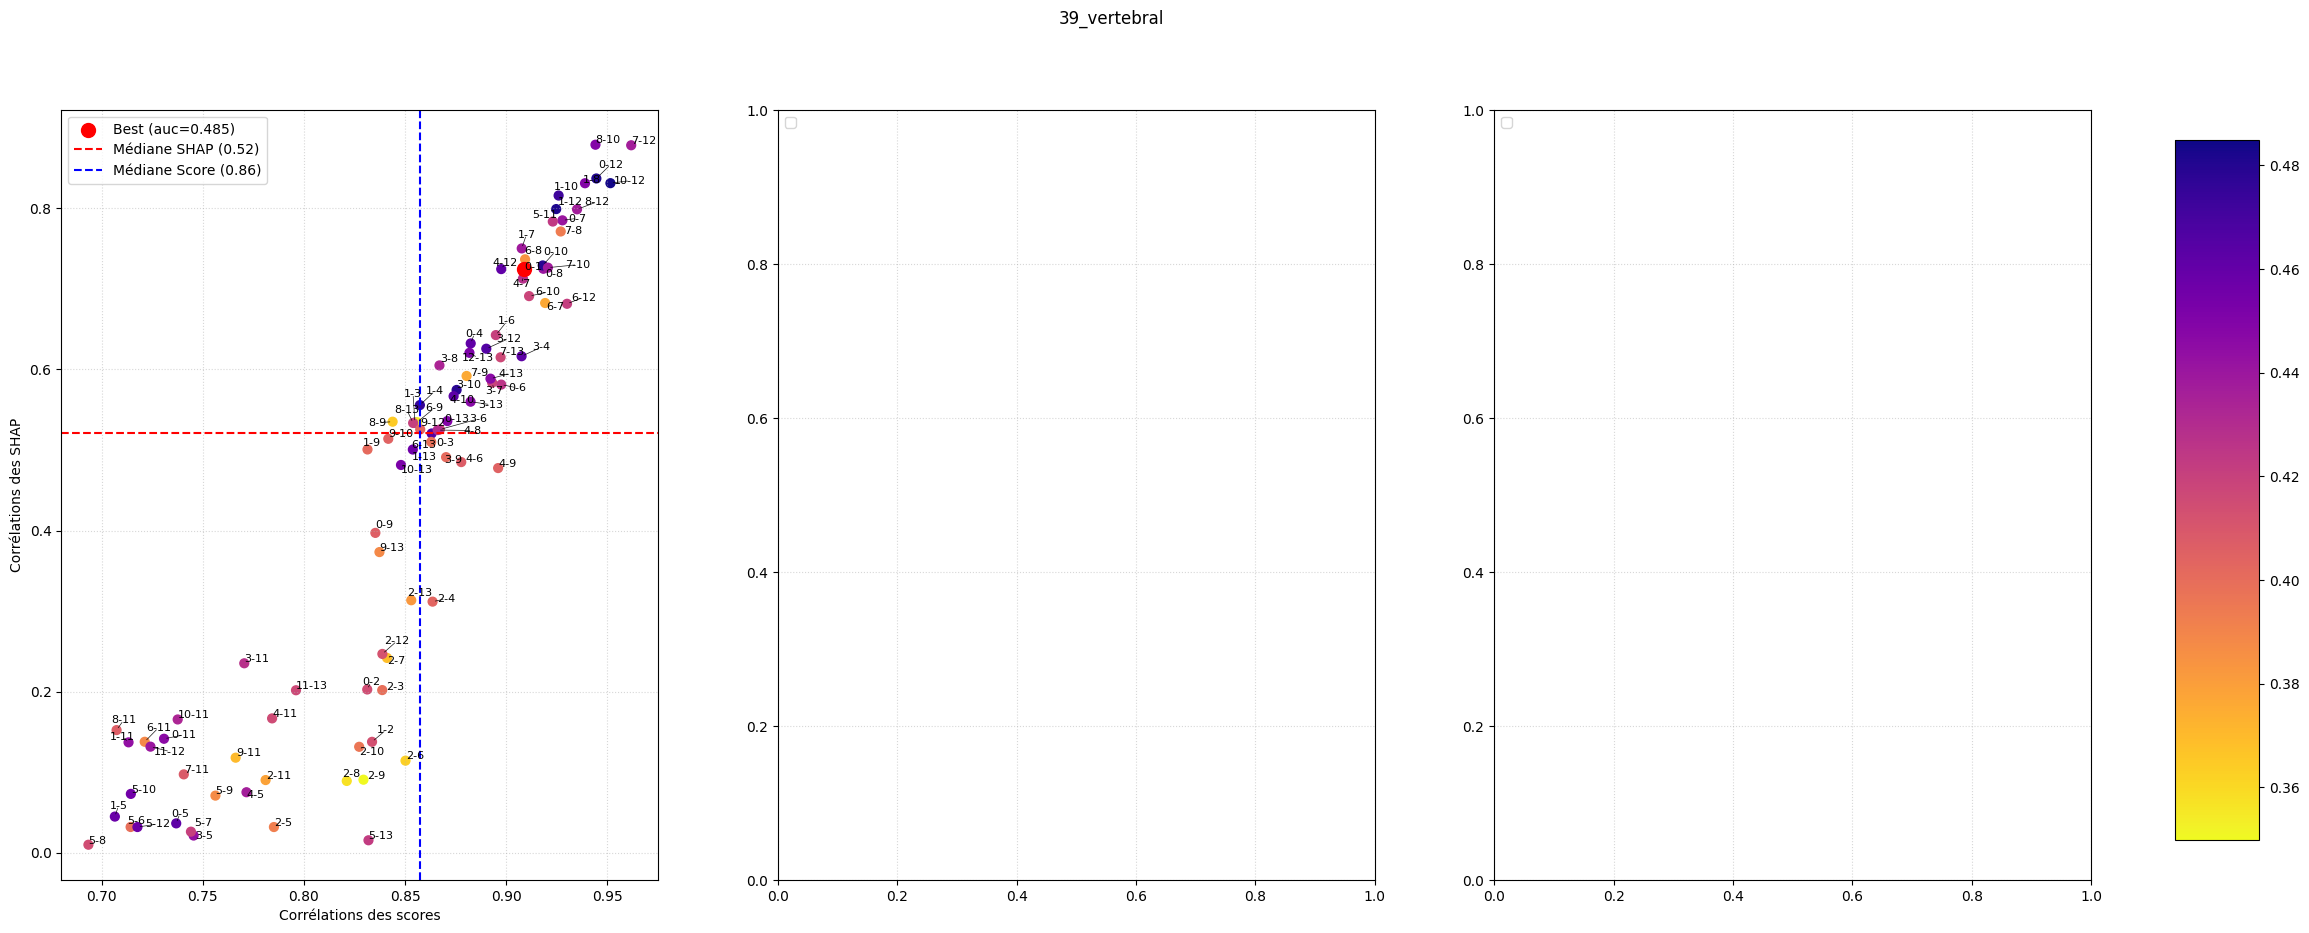

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


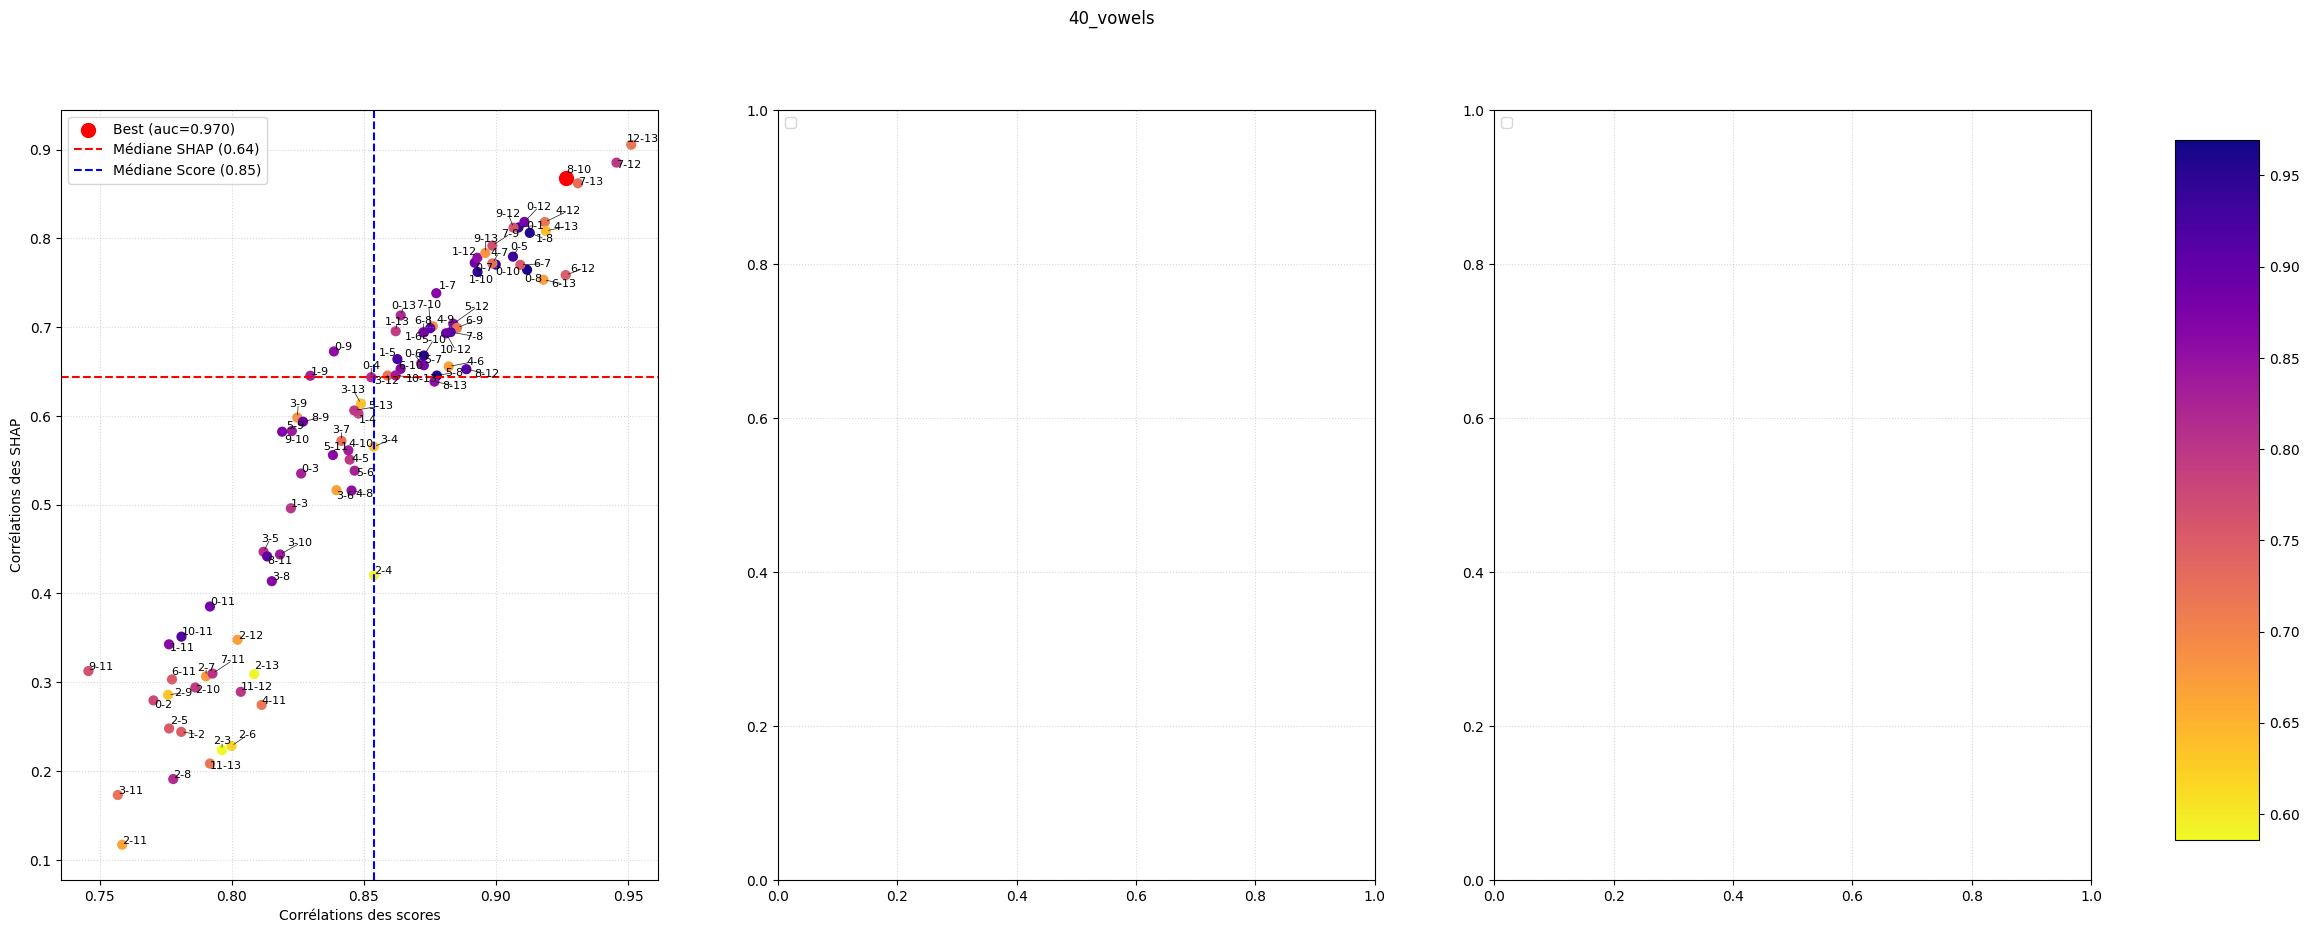

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


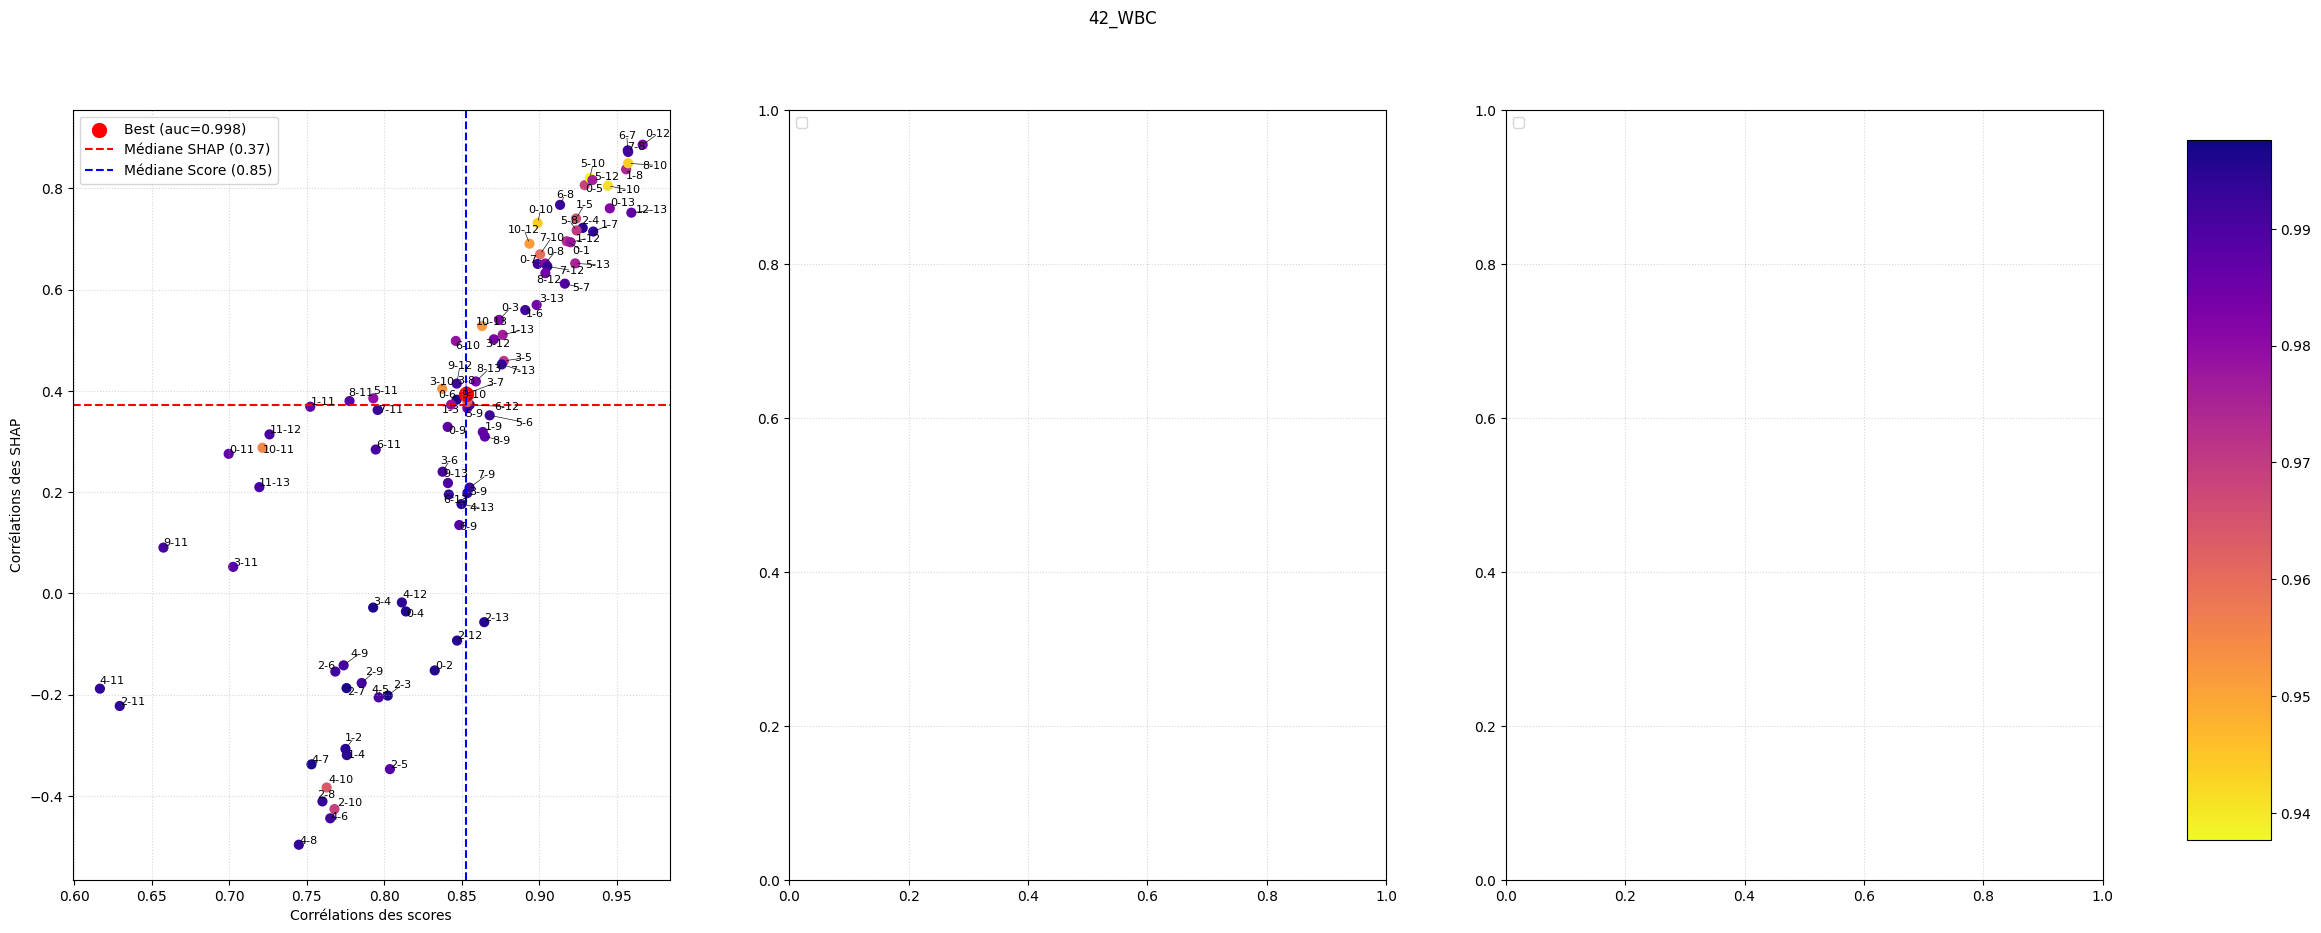

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


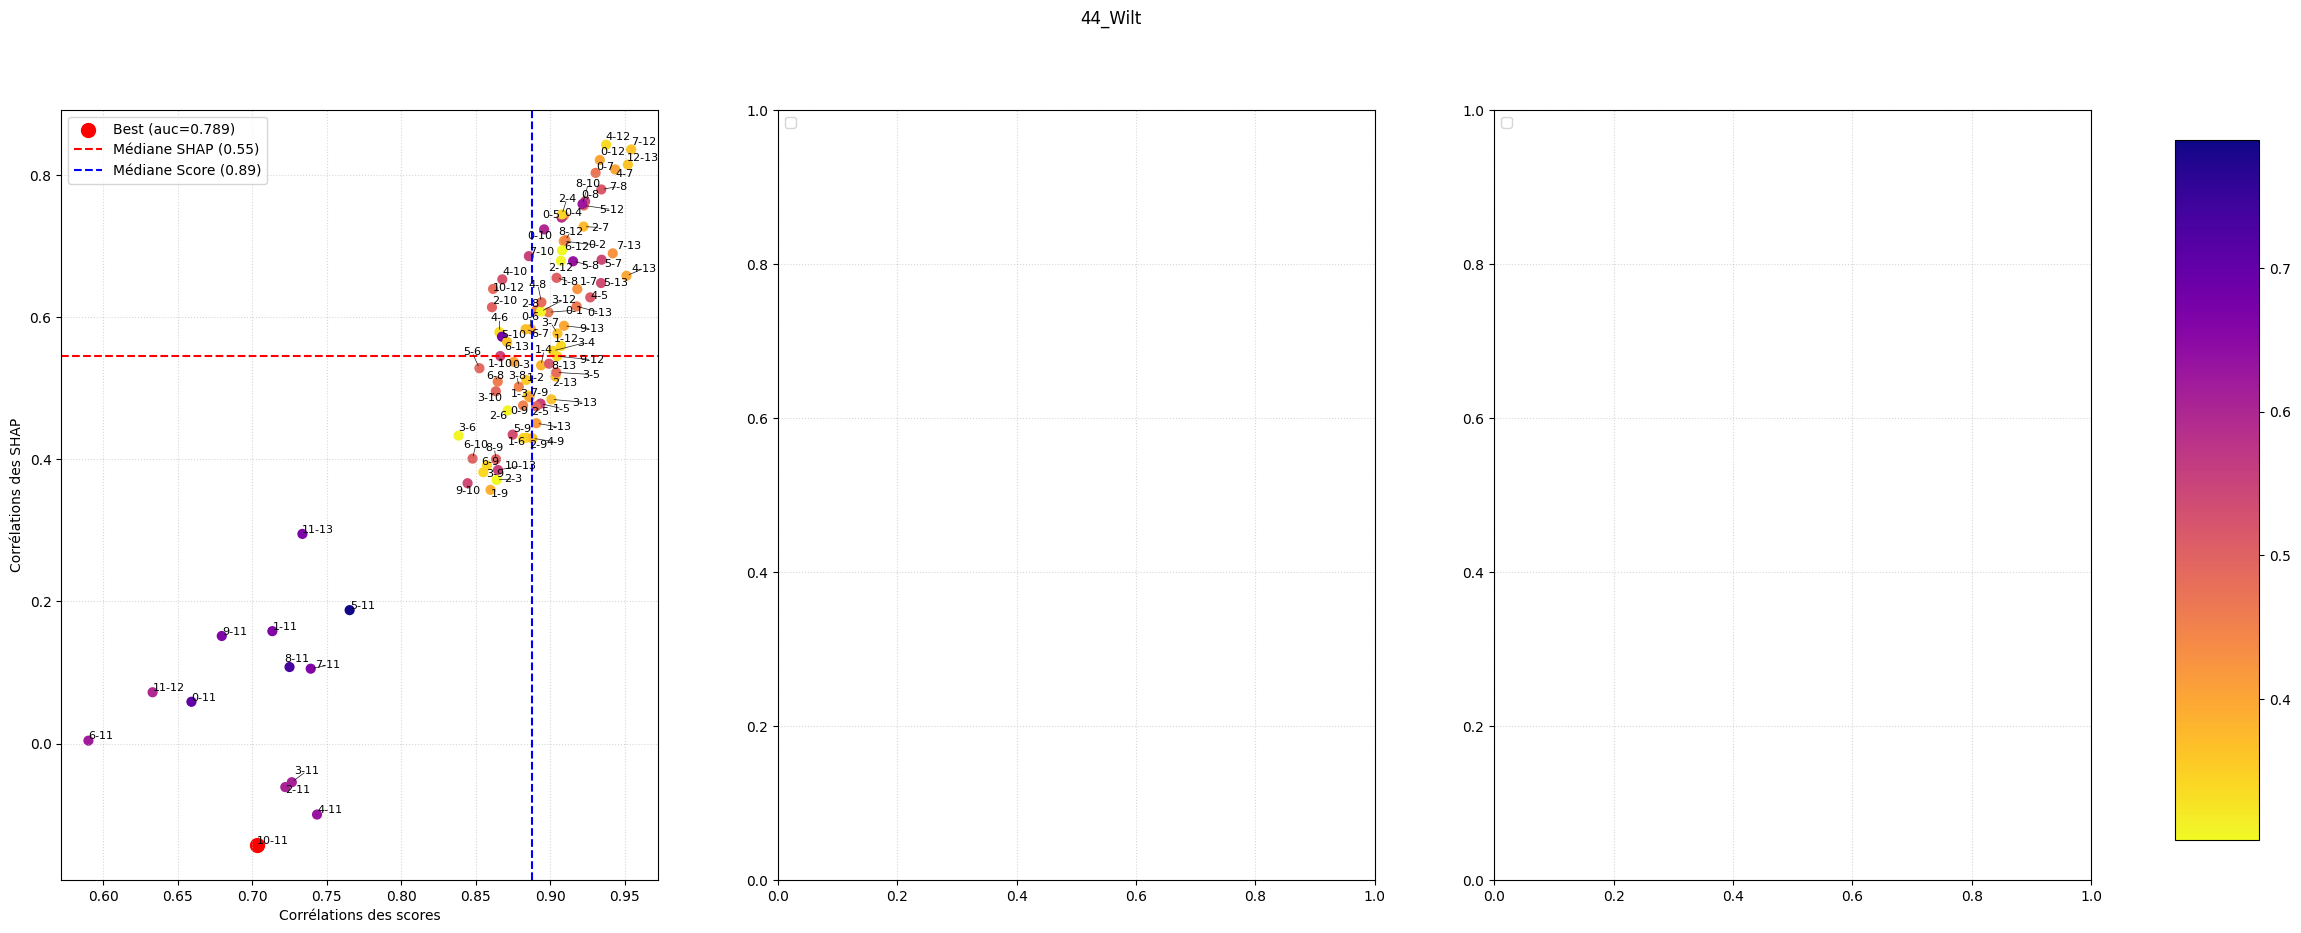

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


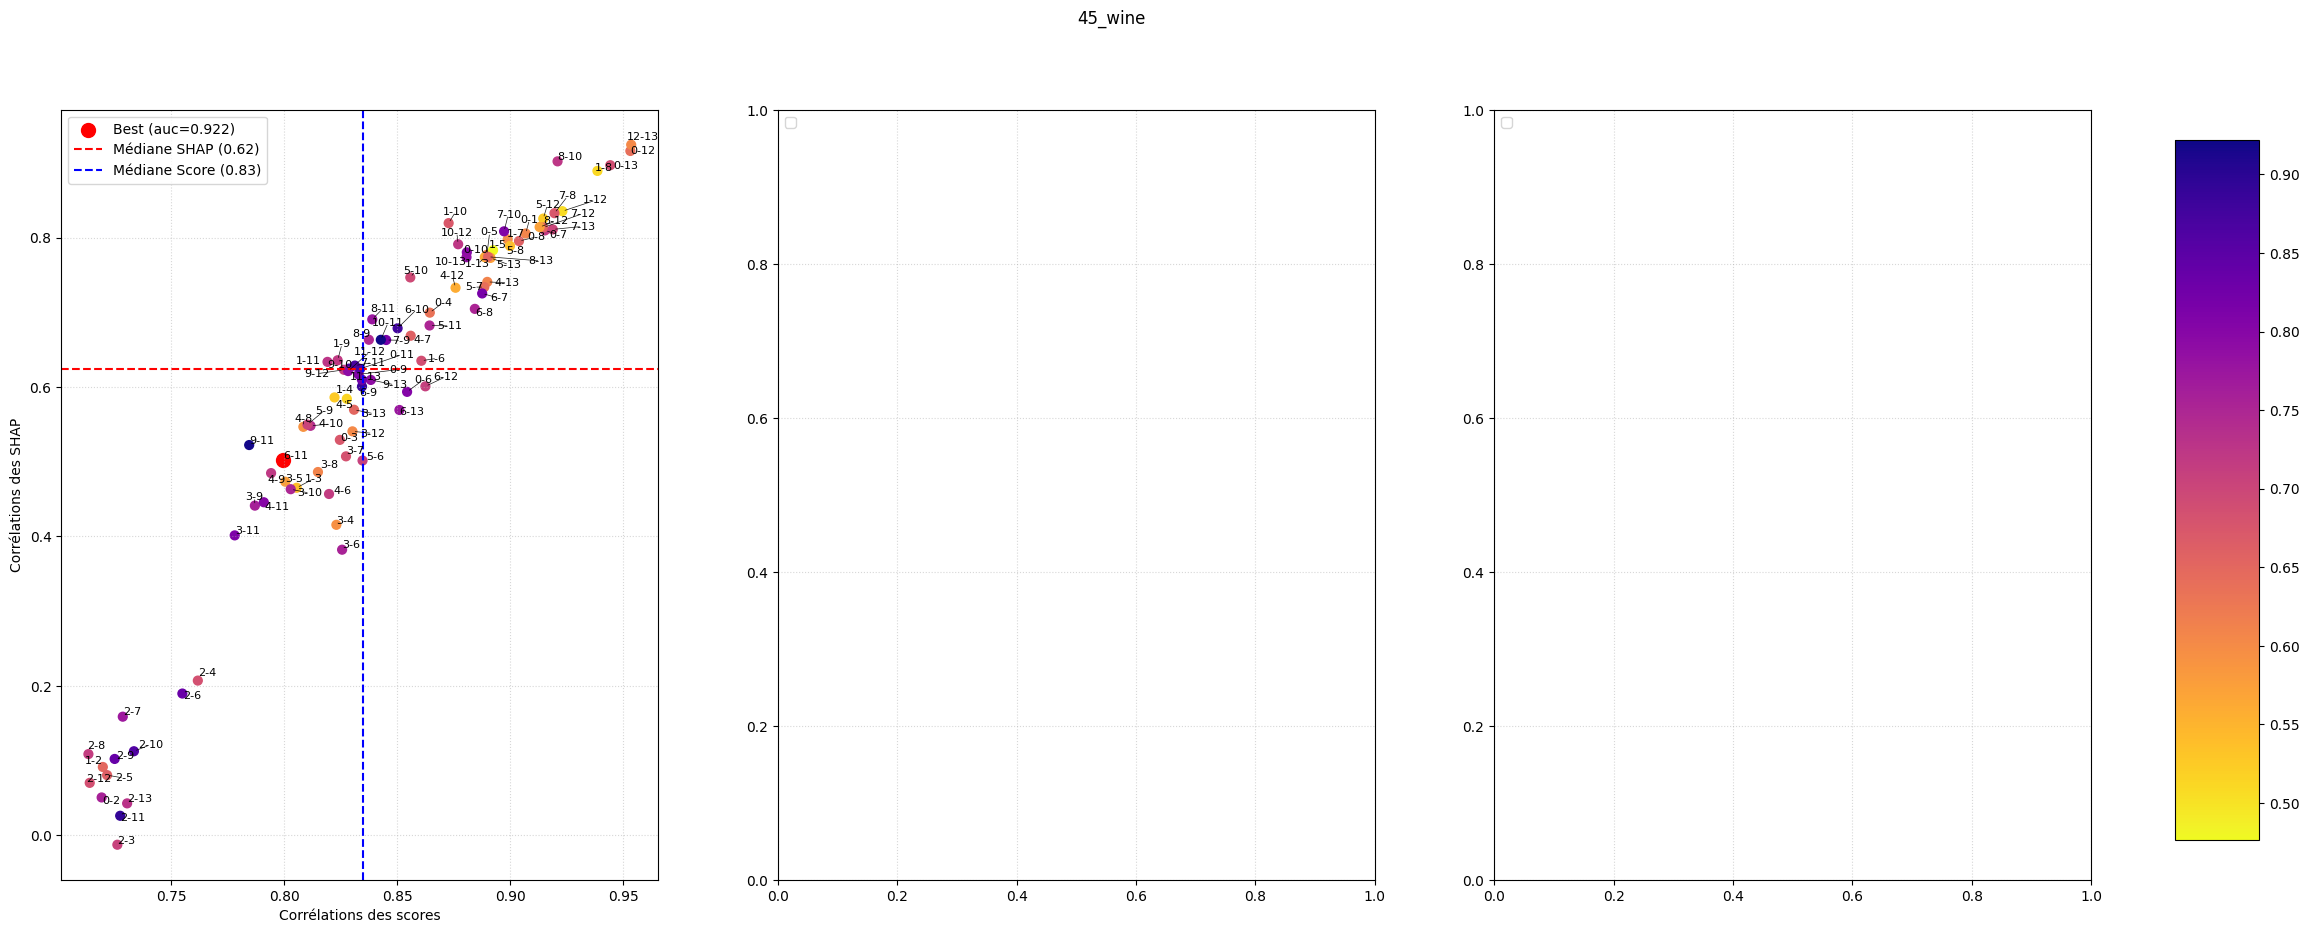

/var/folders/7g/s5gwrw7n4txg22sqn67mby580000gn/T/ipykernel_15733/1419621282.py:77: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left")


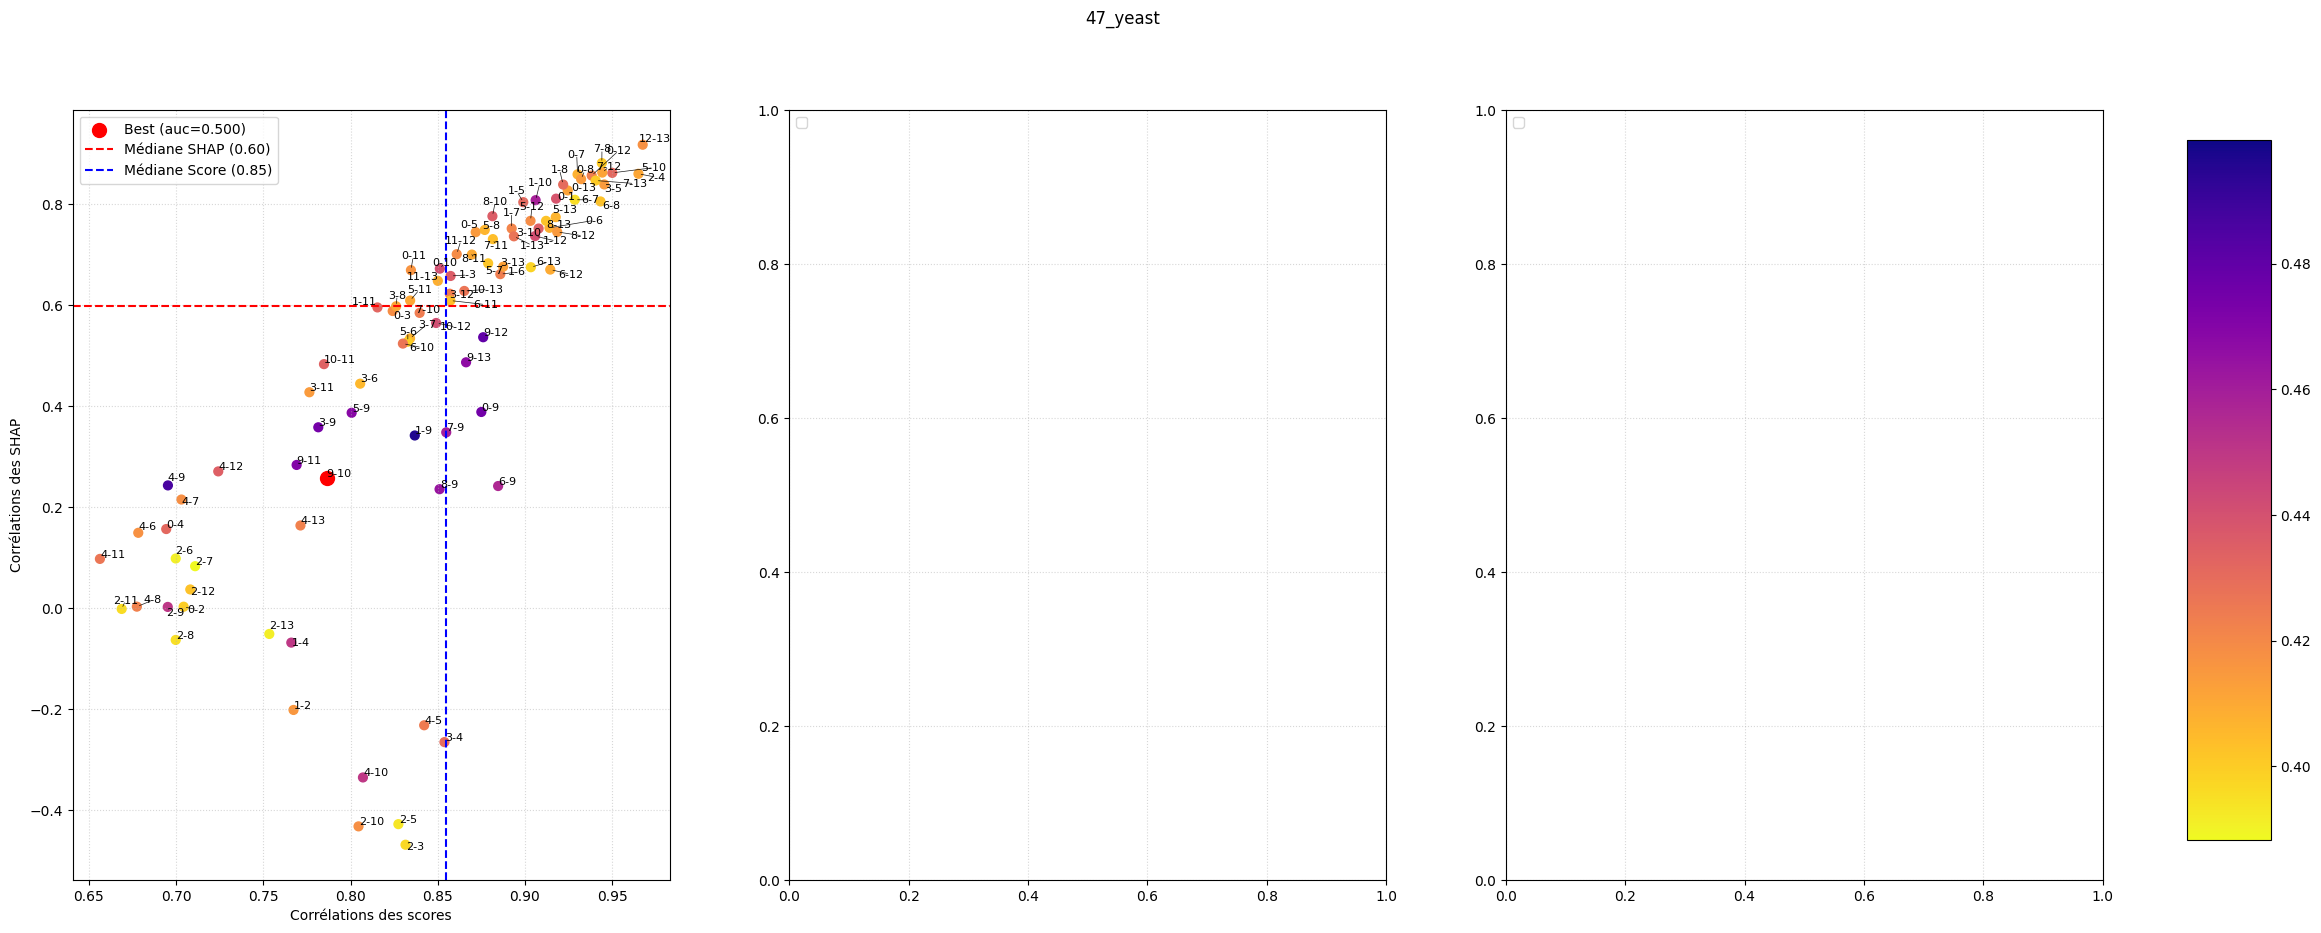

In [3]:
from adjustText import adjust_text


for dataset, data in plot_data.items():

    df = pd.DataFrame(data, columns=["auc_triplet", "name", "SHAP", "NDCG"])

    shap_median = df["SHAP"].median()
    ndcg_median = df["NDCG"].median()

    fig, axs = plt.subplots(1, 3, figsize=(28, 10))

    vmin = df["auc_triplet"].min()
    vmax = df["auc_triplet"].max()

    best_idx = df["auc_triplet"].idxmax()
    best_point_df = df.loc[[best_idx]]
    other_points_df = df.drop(best_idx)

    default_size = 40
    best_size = 100

    # ==========
    # First plot
    # ==========

    sc = axs[0].scatter(
        other_points_df["NDCG"],
        other_points_df["SHAP"],
        c=other_points_df["auc_triplet"],
        cmap="plasma_r",
        s=default_size,
        vmin=vmin,
        vmax=vmax,
    )

    axs[0].scatter(
        best_point_df["NDCG"],
        best_point_df["SHAP"],
        color="red",
        s=best_size,
        # zorder=10,
        label=f"Best (auc={best_point_df['auc_triplet'].values[0]:.3f})",
    )

    texts_ax0 = []

    for n, score, shap in df[["name", "NDCG", "SHAP"]].values:
        texts_ax0.append(axs[0].text(score, shap, n, fontsize=8))

    adjust_text(
        texts_ax0,
        ax=axs[0],
        force_text=(0.2, 0.2),
        force_points=(0.1, 0.1),
        arrowprops=dict(arrowstyle="-", color="black", lw=0.5, alpha=0.9),
    )

    axs[0].axhline(
        shap_median,
        color="red",
        linestyle="--",
        label=f"Médiane SHAP ({shap_median:.2f})",
    )

    axs[0].axvline(
        ndcg_median,
        color="blue",
        linestyle="--",
        label=f"Médiane Score ({ndcg_median:.2f})",
    )

    axs[0].set_xlabel("Corrélations des scores")
    axs[0].set_ylabel("Corrélations des SHAP")

    for ax in axs:
        ax.legend(loc="upper left")
        ax.grid(True, linestyle=":", alpha=0.5)

    fig.subplots_adjust(right=0.85)
    cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
    fig.colorbar(sc, cax=cbar_ax)
    fig.suptitle(f"{dataset}")
    plt.show()